In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("matches_full.csv")

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team']


In [ ]:
df.drop(columns=['notes'], inplace=True, errors='ignore')



In [ ]:
print(df.shape)              # Number of rows and columns

(4318, 28)


In [ ]:
print(df.columns)            # Column names

Index(['Unnamed: 0', 'date', 'time', 'comp', 'round', 'day', 'venue', 'result',
       'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain',
       'formation', 'opp formation', 'referee', 'match report', 'sh', 'sot',
       'dist', 'fk', 'pk', 'pkatt', 'season', 'team'],
      dtype='object')


In [ ]:
print(df.head())             # First few rows

   Unnamed: 0        date   time     comp        round  day venue result   gf  \
0           0  2024-08-17  21:30  La Liga  Matchweek 1  Sat  Away      W  2.0   
1           1  2024-08-24  19:00  La Liga  Matchweek 2  Sat  Home      W  2.0   
2           2  2024-08-27  21:30  La Liga  Matchweek 3  Tue  Away      W  2.0   
3           3  2024-08-31  17:00  La Liga  Matchweek 4  Sat  Home      W  7.0   
4           4  2024-09-15  16:15  La Liga  Matchweek 5  Sun  Away      W  4.0   

    ga  ...              referee  match report    sh   sot  dist   fk pk  \
0  1.0  ...                  NaN  Match Report  17.0   5.0  18.6  1.0  1   
1  1.0  ...                  NaN  Match Report  13.0   5.0  16.6  0.0  0   
2  1.0  ...                  NaN  Match Report  22.0   5.0  19.3  1.0  0   
3  0.0  ...  Isidro Díaz de Mera  Match Report  23.0  11.0  13.7  1.0  0   
4  1.0  ...      Alejandro Muñíz  Match Report  20.0   9.0  19.1  0.0  0   

  pkatt season       team  
0     1   2025  Barcelona  


In [ ]:
print(df.describe())

        Unnamed: 0           gf           ga           xg          xga  \
count  4318.000000  4318.000000  4318.000000  4318.000000  4318.000000   
mean     21.691524     1.270032     1.270032     1.262112     1.262112   
std      13.893162     1.168970     1.168970     0.774208     0.774208   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       9.000000     0.000000     0.000000     0.700000     0.700000   
50%      21.000000     1.000000     1.000000     1.100000     1.100000   
75%      33.000000     2.000000     2.000000     1.700000     1.700000   
max      58.000000     7.000000     7.000000     5.900000     5.900000   

              poss    attendance           sh          sot         dist  \
count  4318.000000   3344.000000  4318.000000  4318.000000  4315.000000   
mean     50.001158  27864.883373    11.512043     3.785086    18.184774   
std      11.435318  18103.653603     4.838242     2.288167     3.413213   
min      18.000000     13.000000 

In [ ]:
print(df.describe(include='object'))

              date   time     comp        round   day venue result  opponent  \
count         4318   4318     4318         4318  4318  4318   4318      4318   
unique         772     21        1           38     7     2      3        27   
top     2020-07-16  21:00  La Liga  Matchweek 1   Sun  Away      W  Valencia   
freq            20   1242     4318          120  1626  2159   1566       216   

       captain formation opp formation     referee  match report       team  
count     4318      4318          4318        4264          4318       4318  
unique     223        22            21          33             1         27  
top       Koke     4-4-2         4-4-2  César Soto  Match Report  Barcelona  
freq       169      1206          1206         230          4318        216  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4318 entries, 0 to 4317
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4318 non-null   int64  
 1   date           4318 non-null   object 
 2   time           4318 non-null   object 
 3   comp           4318 non-null   object 
 4   round          4318 non-null   object 
 5   day            4318 non-null   object 
 6   venue          4318 non-null   object 
 7   result         4318 non-null   object 
 8   gf             4318 non-null   float64
 9   ga             4318 non-null   float64
 10  opponent       4318 non-null   object 
 11  xg             4318 non-null   float64
 12  xga            4318 non-null   float64
 13  poss           4318 non-null   float64
 14  attendance     3344 non-null   float64
 15  captain        4318 non-null   object 
 16  formation      4318 non-null   object 
 17  opp formation  4318 non-null   object 
 18  referee 

Missing Value

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Unnamed: 0         0
date               0
time               0
comp               0
round              0
day                0
venue              0
result             0
gf                 0
ga                 0
opponent           0
xg                 0
xga                0
poss               0
attendance       974
captain            0
formation          0
opp formation      0
referee           54
match report       0
sh                 0
sot                0
dist               3
fk                 0
pk                 0
pkatt              0
season             0
team               0
dtype: int64


Mean , min , max

In [ ]:
num_summary = df.describe().loc[['mean', 'min', 'max']]
print(num_summary)

      Unnamed: 0        gf        ga        xg       xga       poss  \
mean   21.691524  1.270032  1.270032  1.262112  1.262112  50.001158   
min     0.000000  0.000000  0.000000  0.000000  0.000000  18.000000   
max    58.000000  7.000000  7.000000  5.900000  5.900000  82.000000   

        attendance         sh        sot       dist        fk        pk  \
mean  27864.883373  11.512043   3.785086  18.184774  0.453219  0.129921   
min      13.000000   0.000000   0.000000   4.800000  0.000000  0.000000   
max   95745.000000  36.000000  17.000000  46.200000  5.000000  3.000000   

         pkatt       season  
mean  0.169291  2022.359889  
min   0.000000  2020.000000  
max   3.000000  2025.000000  


Data type

In [ ]:
print(df.dtypes)

Unnamed: 0         int64
date              object
time              object
comp              object
round             object
day               object
venue             object
result            object
gf               float64
ga               float64
opponent          object
xg               float64
xga              float64
poss             float64
attendance       float64
captain           object
formation         object
opp formation     object
referee           object
match report      object
sh               float64
sot              float64
dist             float64
fk               float64
pk                 int64
pkatt              int64
season             int64
team              object
dtype: object


In [ ]:
def count_outliers(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((df[column] < lower) | (df[column] > upper)).sum()

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
outliers = {col: count_outliers(col) for col in numeric_cols}
print("\nOutlier Counts:\n", outliers)


Outlier Counts:
 {'Unnamed: 0': np.int64(0), 'gf': np.int64(15), 'ga': np.int64(15), 'xg': np.int64(85), 'xga': np.int64(85), 'poss': np.int64(0), 'attendance': np.int64(52), 'sh': np.int64(78), 'sot': np.int64(80), 'dist': np.int64(85), 'fk': np.int64(66), 'pk': np.int64(522), 'pkatt': np.int64(662), 'season': np.int64(0)}


Column relationships

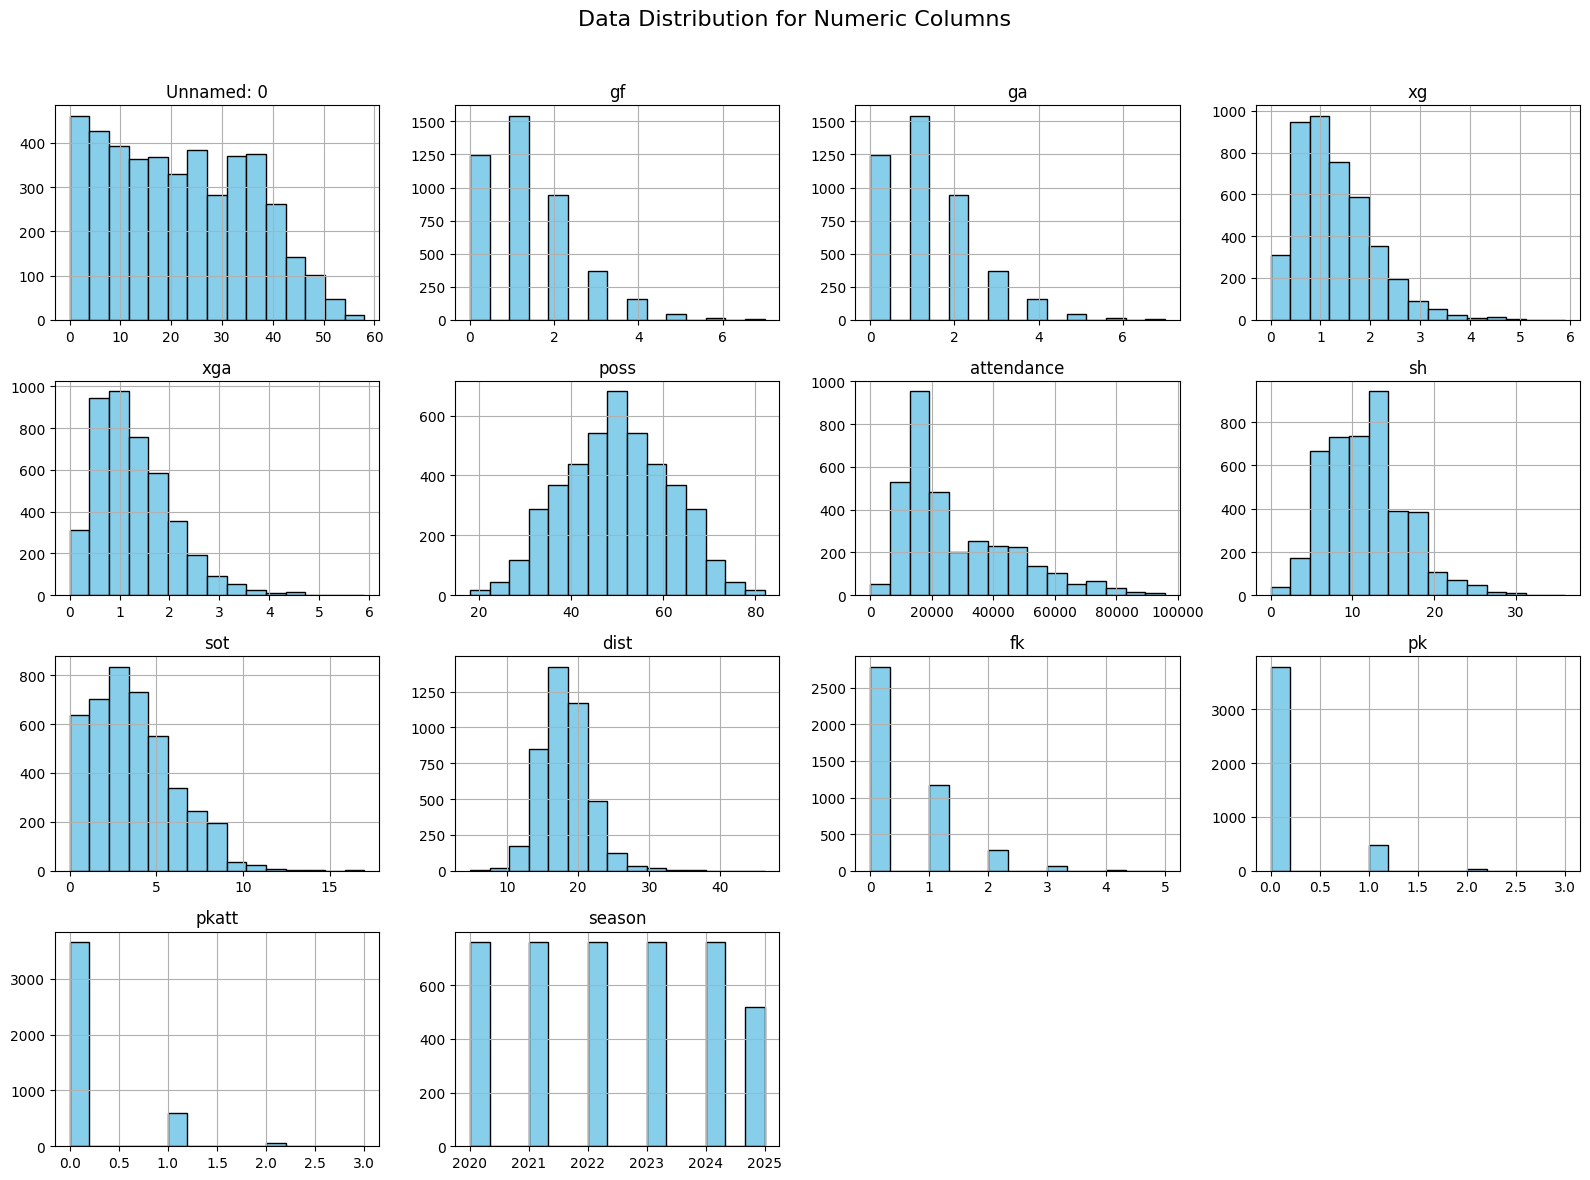

In [ ]:
df[numeric_cols].hist(bins=15, edgecolor='black', color='skyblue', figsize=(16, 12))
plt.suptitle("Data Distribution for Numeric Columns", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Categorical columns Number


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))
print("Number of categorical columns:", len(categorical_cols))


Categorical columns: ['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'opponent', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'team']
Number of categorical columns: 14


In [ ]:
# 5. Correlation Matrix
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
print("\nCorrelation Matrix:\n", correlation_matrix)



Correlation Matrix:
             Unnamed: 0        gf        ga        xg       xga      poss  \
Unnamed: 0    1.000000  0.040602 -0.026077  0.046992 -0.022778  0.066031   
gf            0.040602  1.000000 -0.023200  0.599713 -0.070648  0.115663   
ga           -0.026077 -0.023200  1.000000 -0.070648  0.599713 -0.115693   
xg            0.046992  0.599713 -0.070648  1.000000 -0.163997  0.295998   
xga          -0.022778 -0.070648  0.599713 -0.163997  1.000000 -0.295892   
poss          0.066031  0.115663 -0.115693  0.295998 -0.295892  1.000000   
attendance    0.103696  0.042520  0.042520  0.072292  0.072292  0.000006   
sh            0.034030  0.252702 -0.054188  0.612979 -0.206036  0.438335   
sot           0.053934  0.551618 -0.050005  0.592698 -0.131212  0.276466   
dist         -0.051438 -0.224966  0.036154 -0.339712  0.070573 -0.079873   
fk            0.001810  0.004419 -0.018605  0.080020 -0.055559  0.147138   
pk           -0.013188  0.271764  0.014482  0.366244 -0.013563  0.

In [ ]:
# 3. Number of Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nNumber of Categorical Columns:", len(categorical_cols))


Number of Categorical Columns: 14


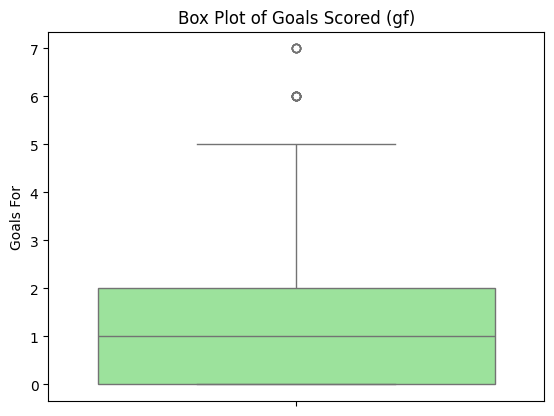

In [ ]:
# 2. Box Plot of 'gf' (Goals For)
plt.figure()
sns.boxplot(data=df, y='gf', color='lightgreen')
plt.title("Box Plot of Goals Scored (gf)")
plt.ylabel("Goals For")
plt.show()

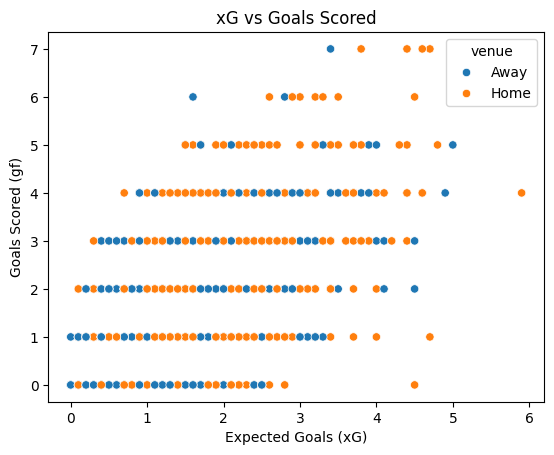

In [ ]:
# 3. Scatter Plot of xG vs Goals Scored
plt.figure()
sns.scatterplot(data=df, x='xg', y='gf', hue='venue')
plt.title("xG vs Goals Scored")
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Goals Scored (gf)")
plt.show()

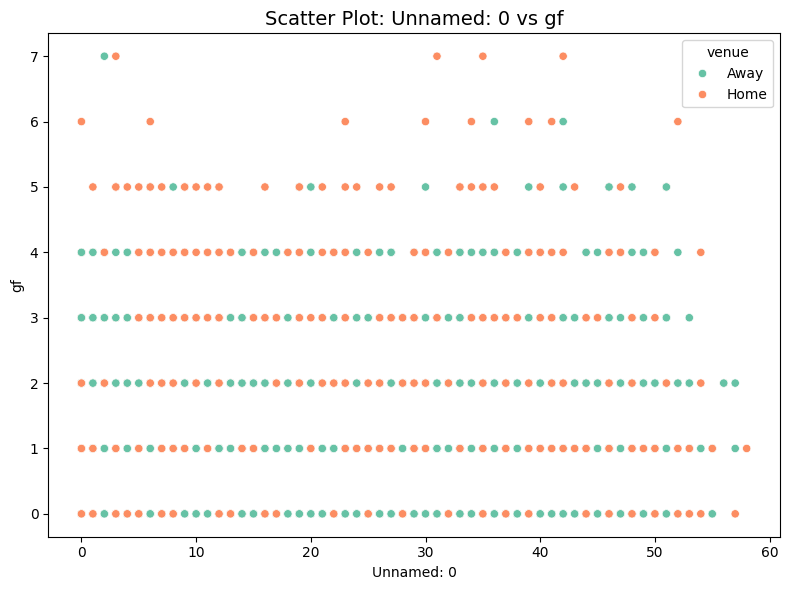

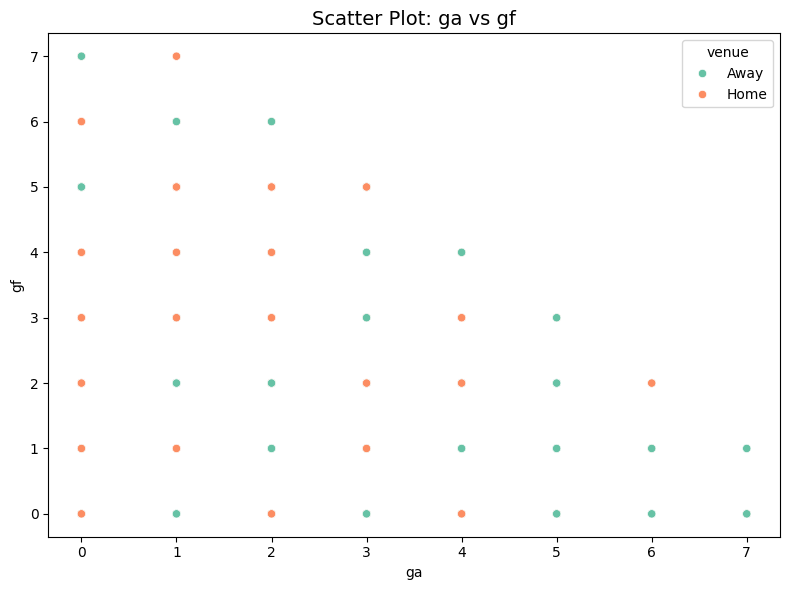

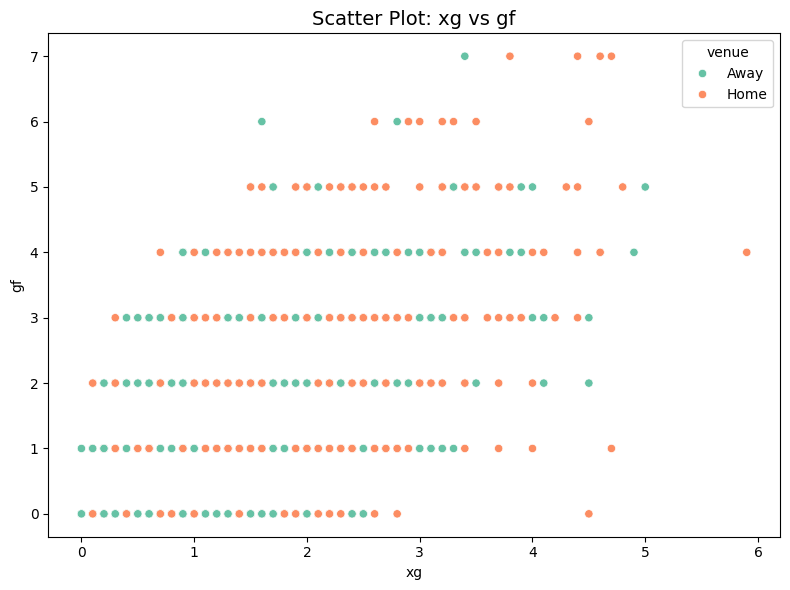

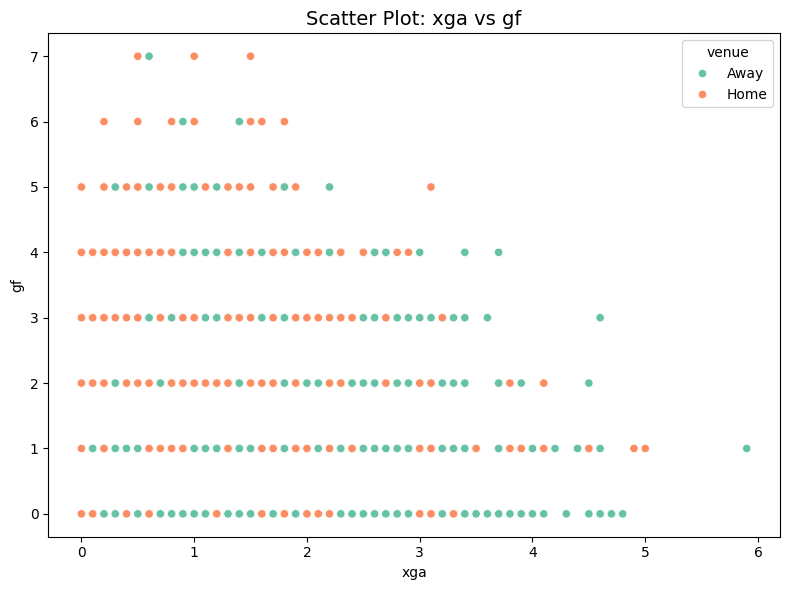

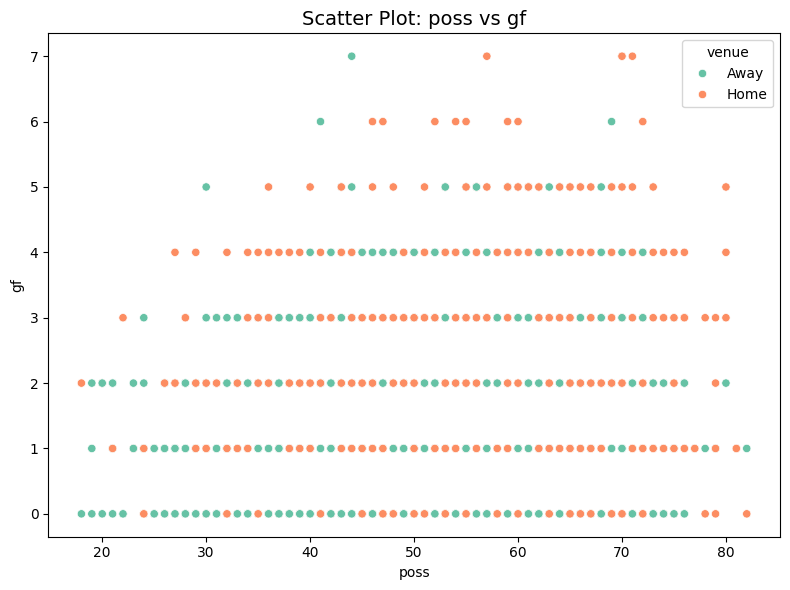

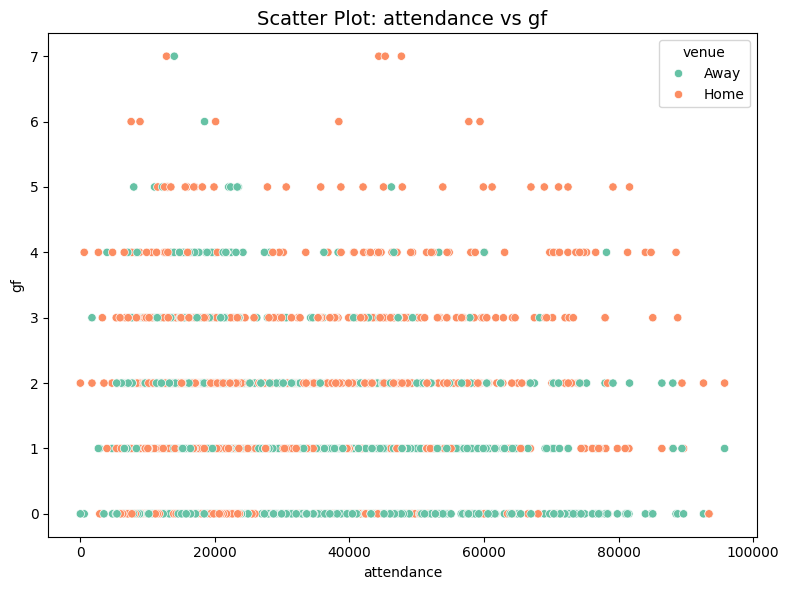

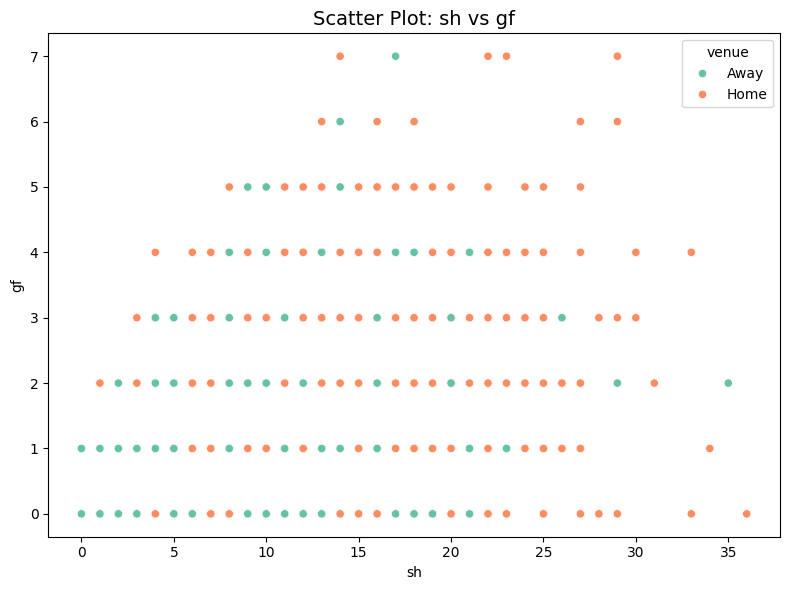

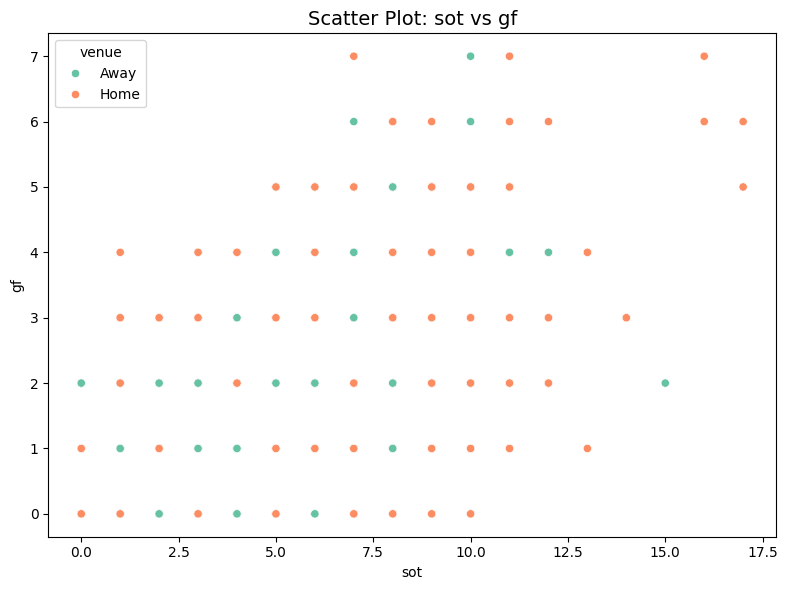

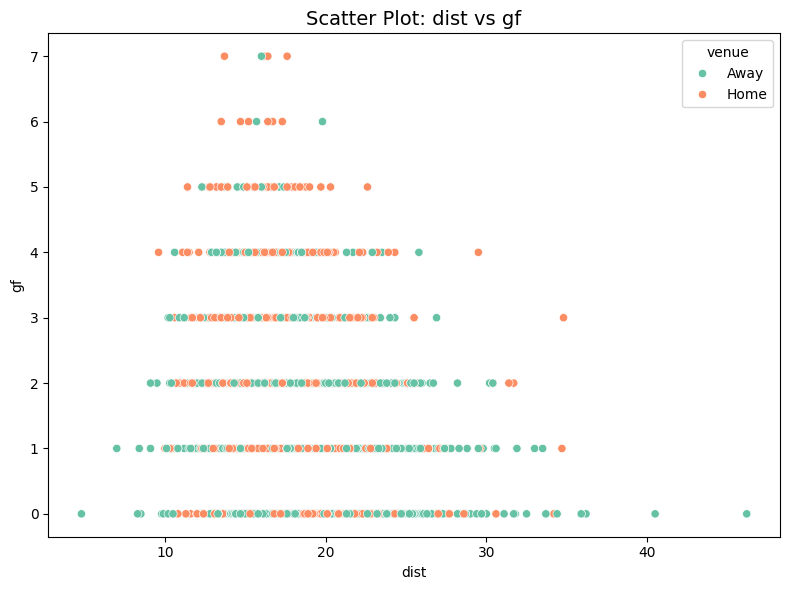

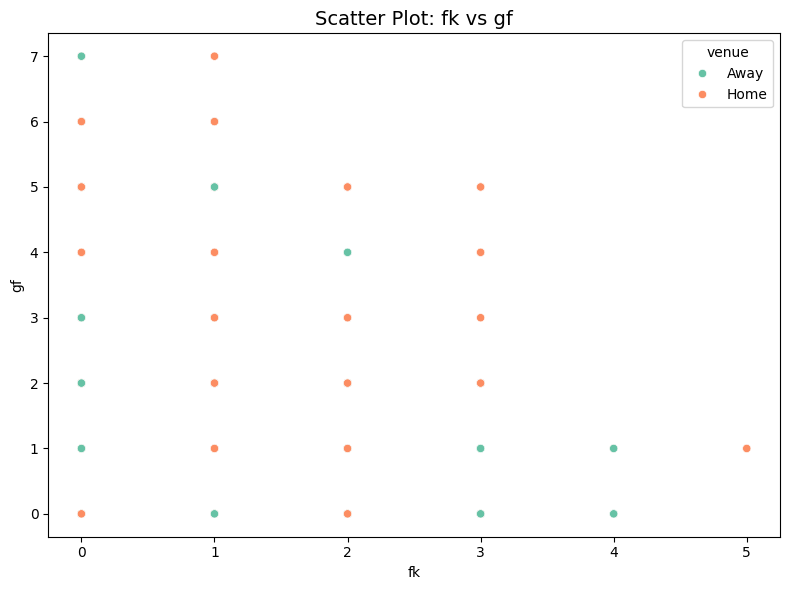

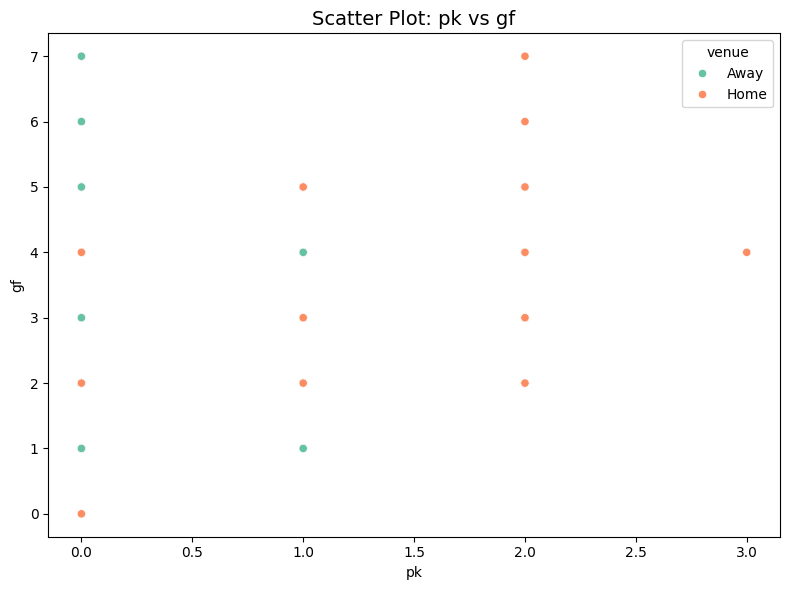

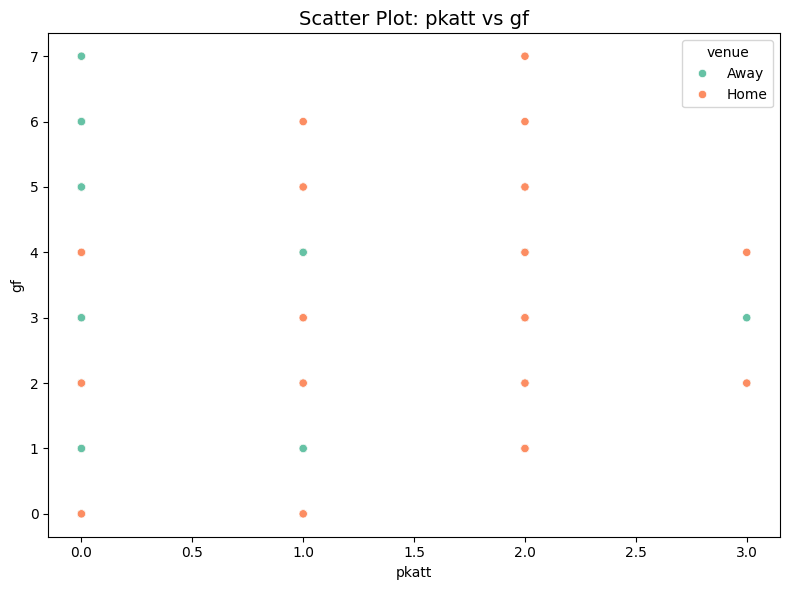

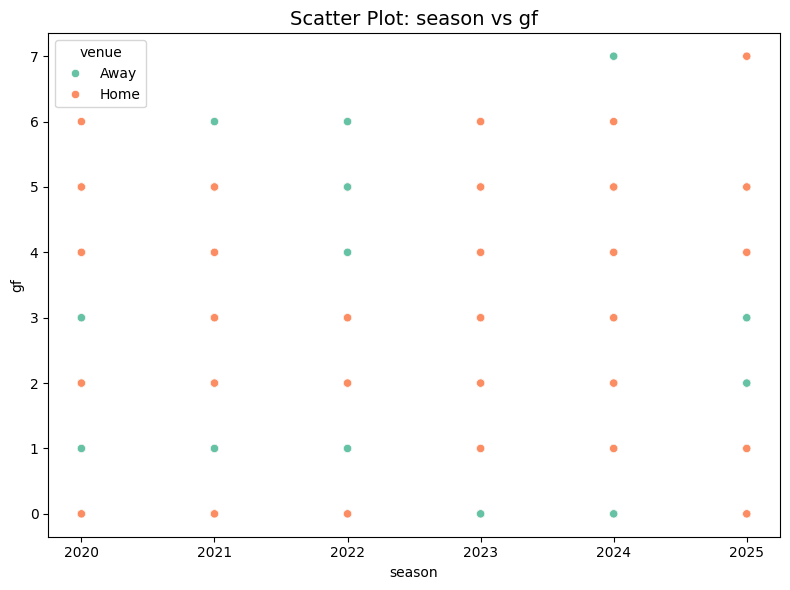

In [ ]:
# Choose a target column to compare against
target_col = 'gf'  # You can also use 'xg' or others

# Loop through numeric columns
for col in numeric_cols:
    if col == target_col:
        continue  # skip plotting against itself

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=col, y=target_col, hue='venue', palette='Set2')
    plt.title(f"Scatter Plot: {col} vs {target_col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.tight_layout()
    plt.show()



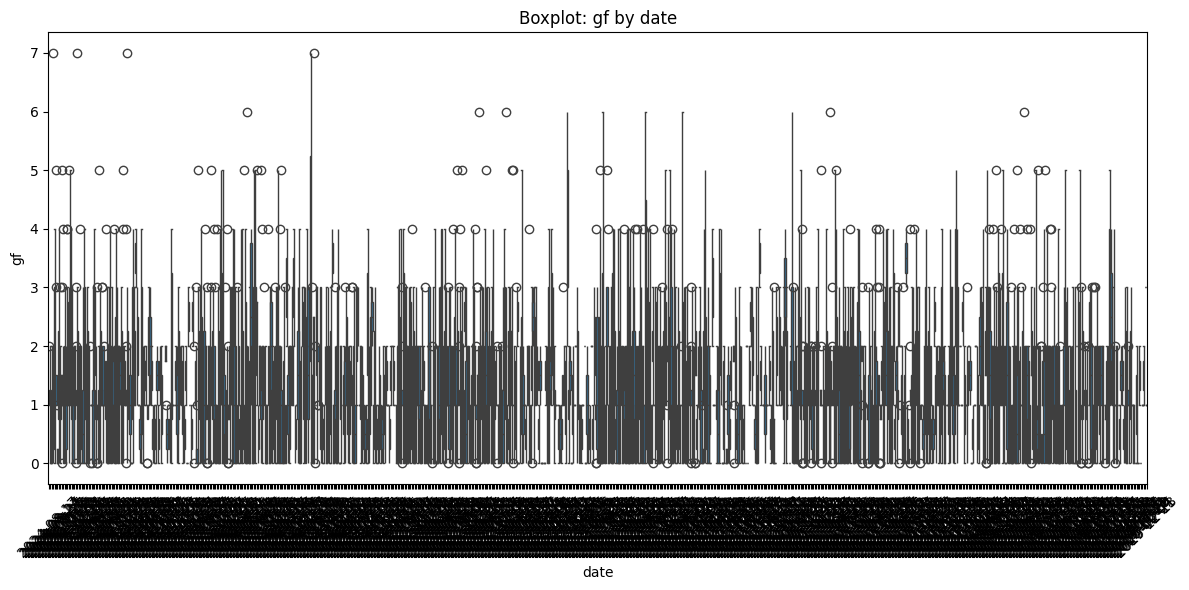

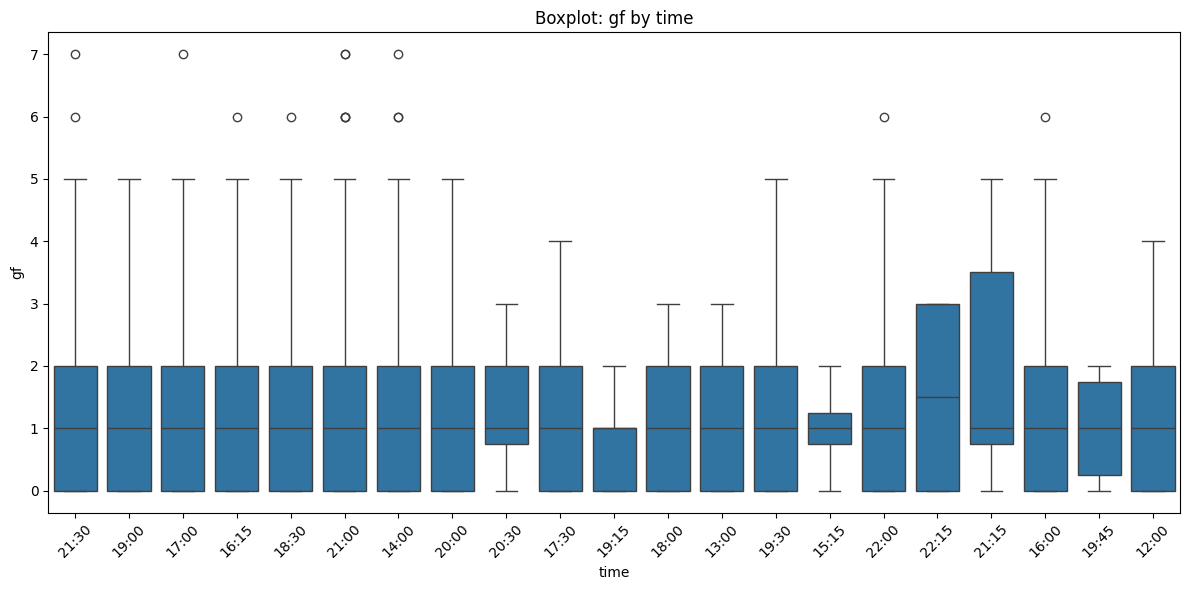

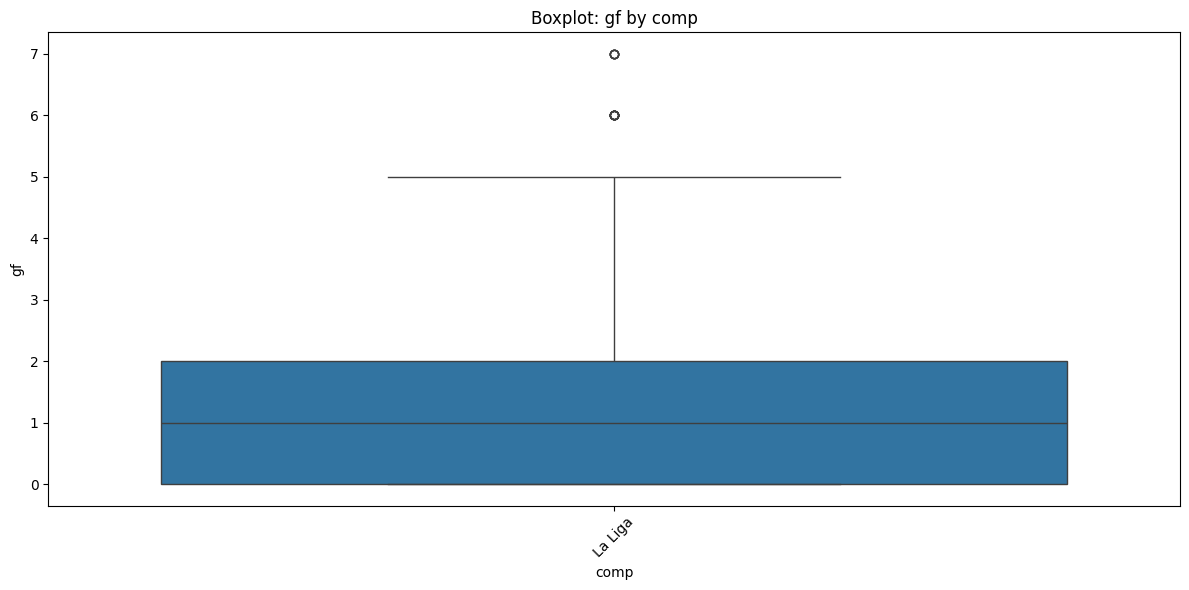

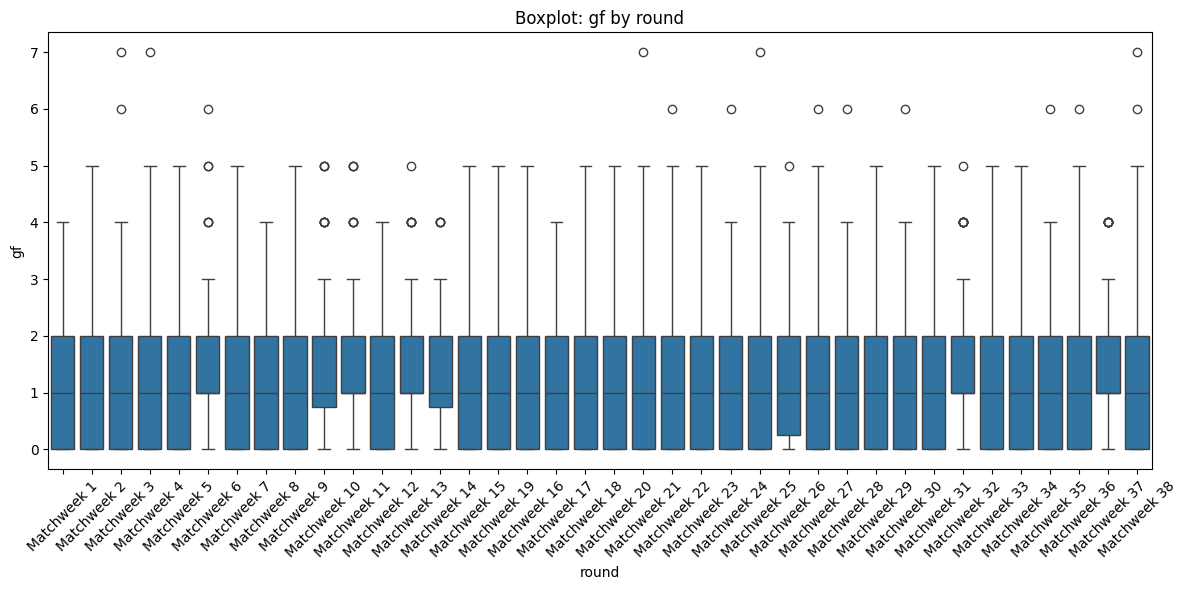

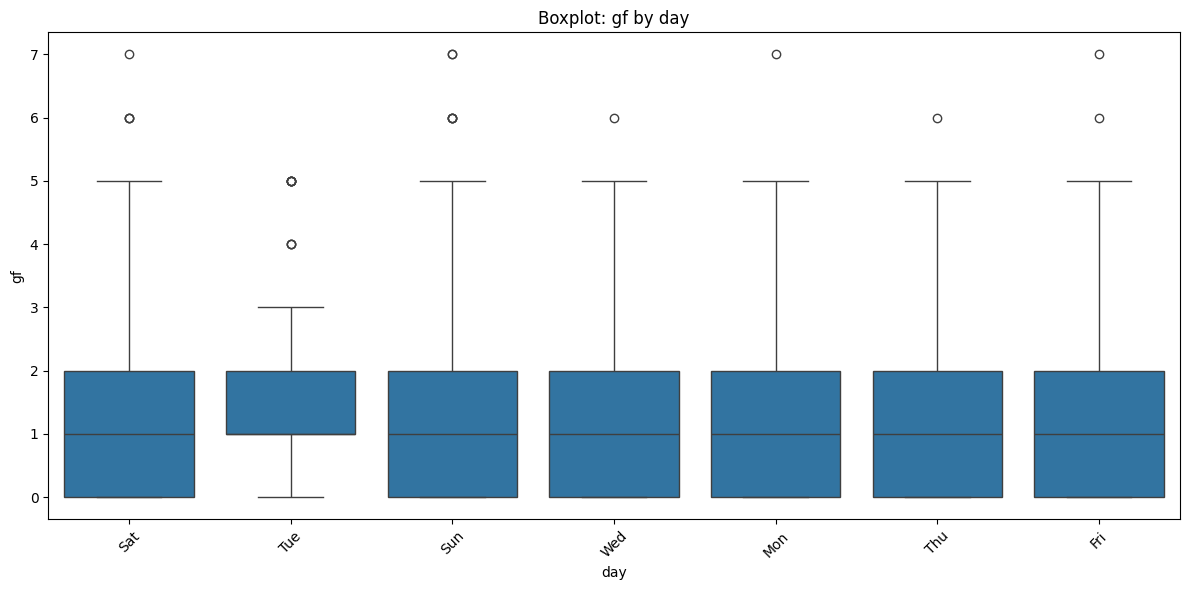

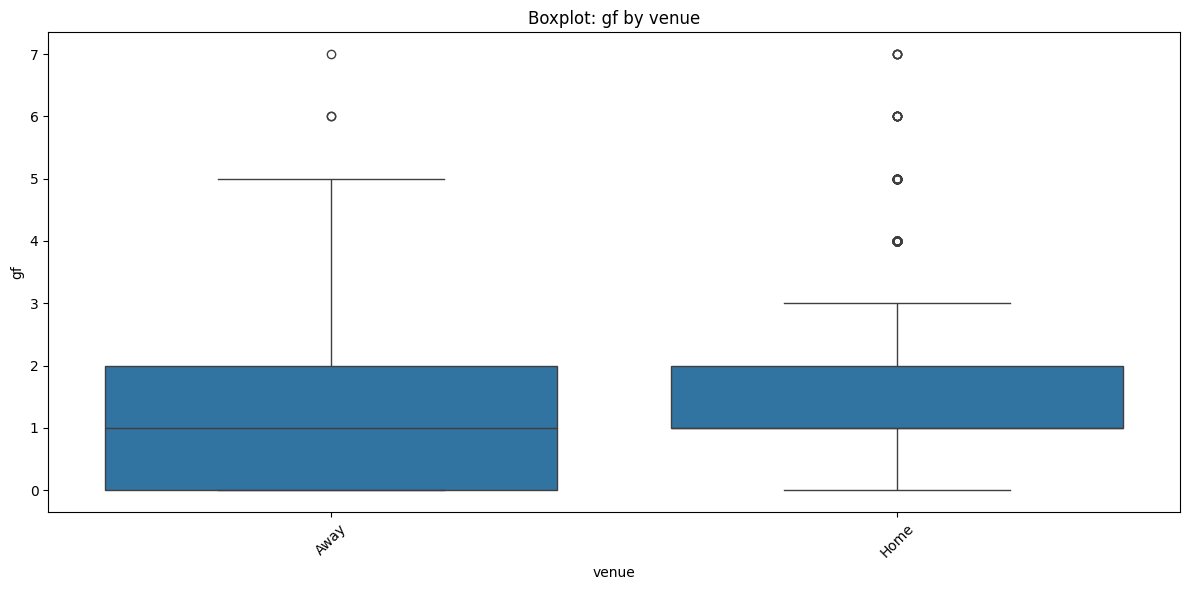

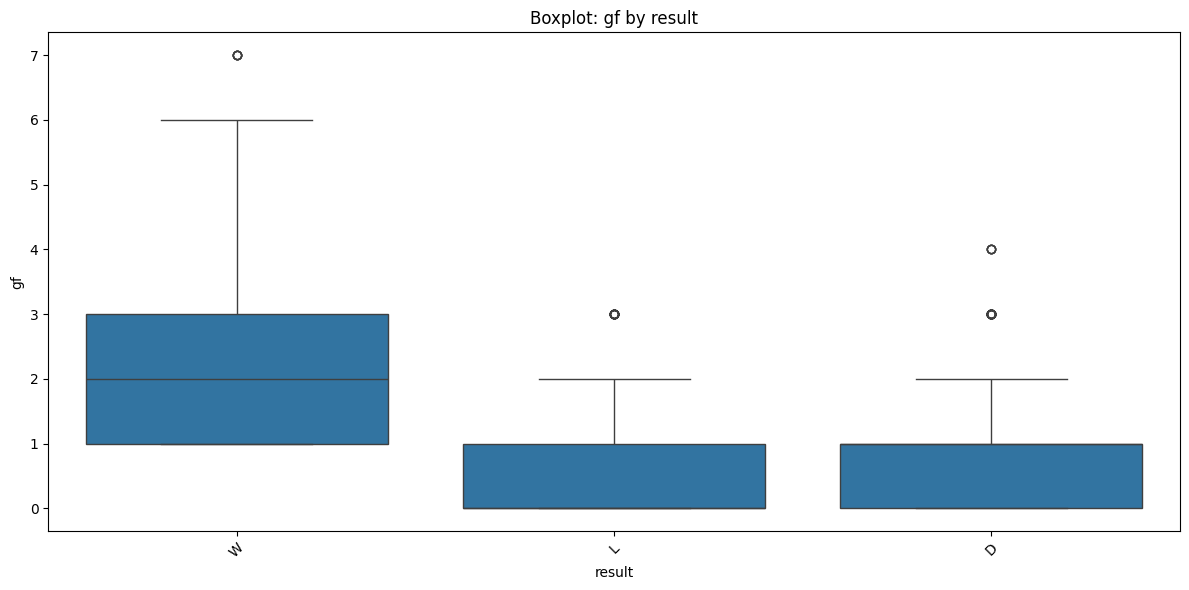

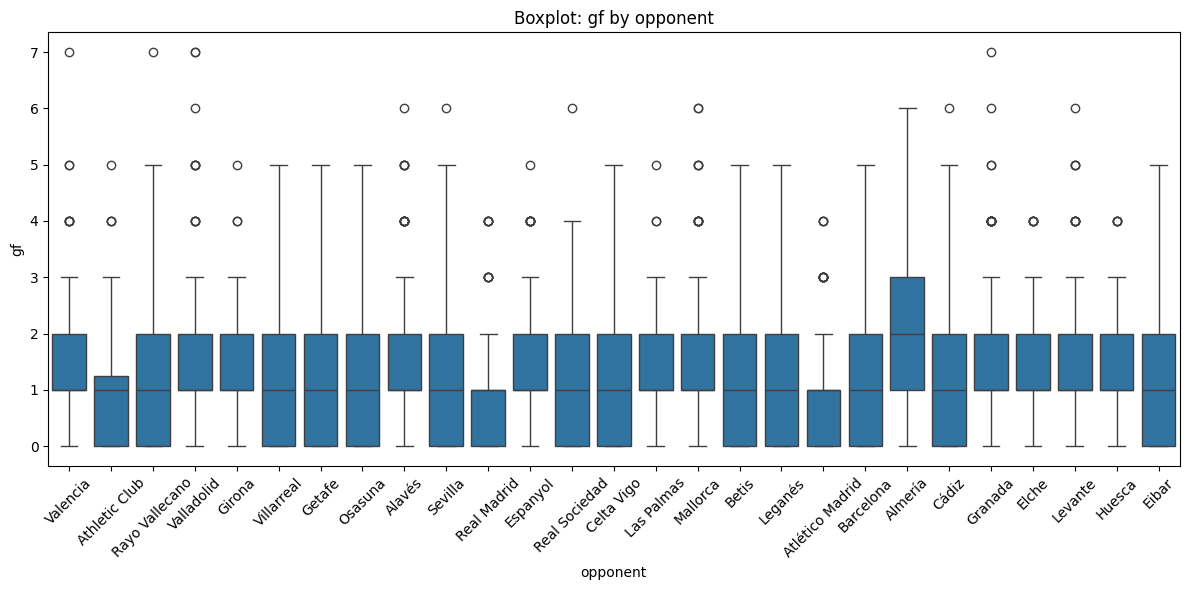

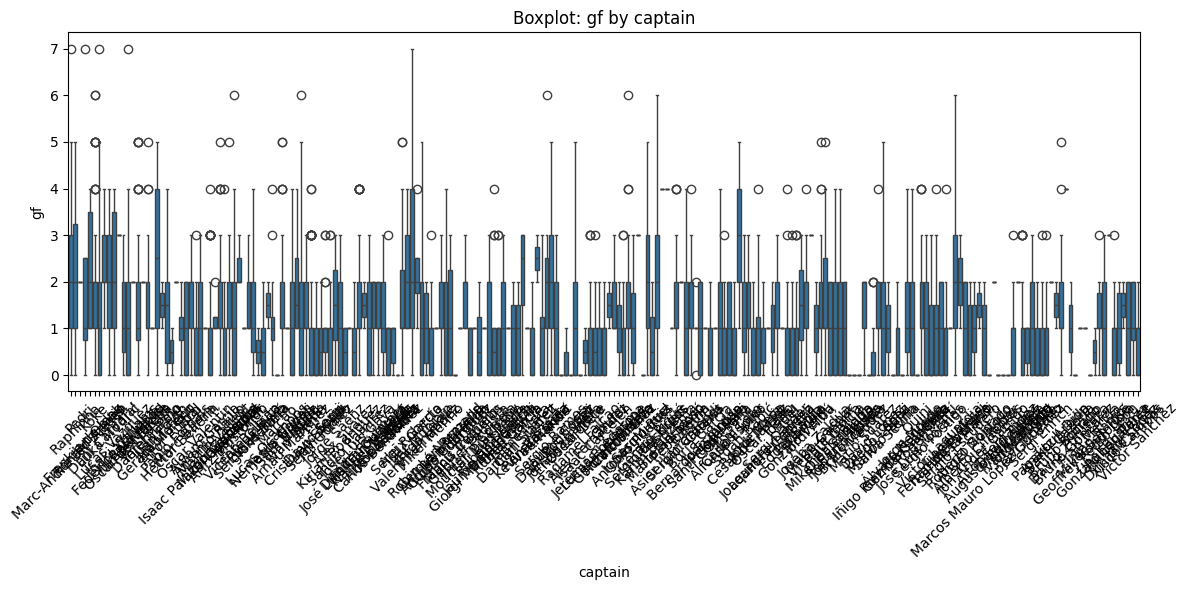

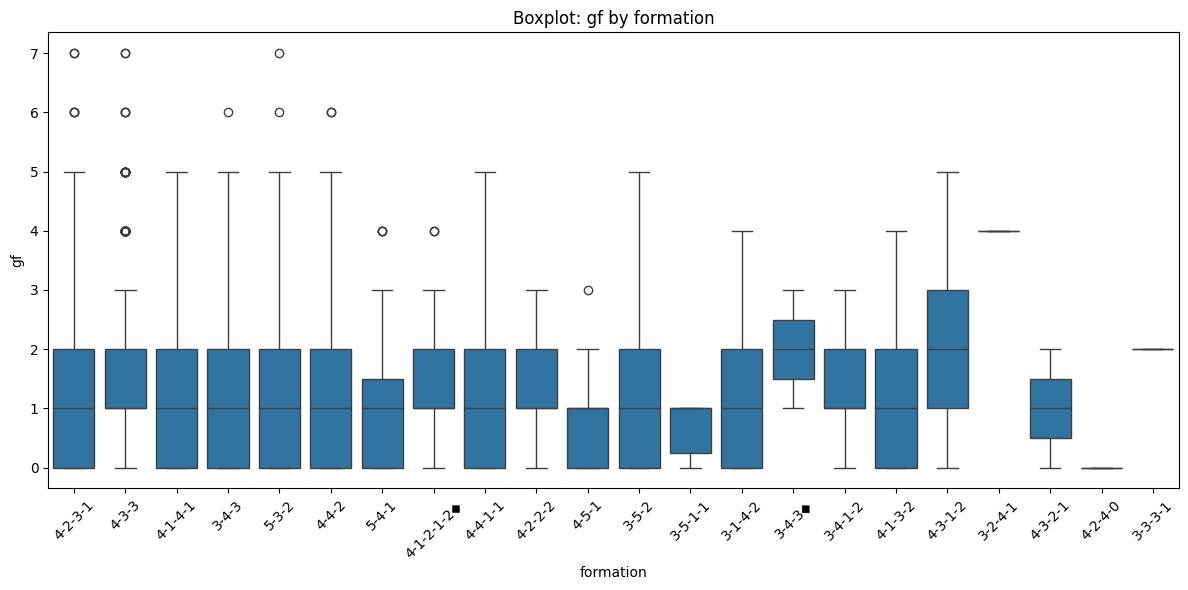

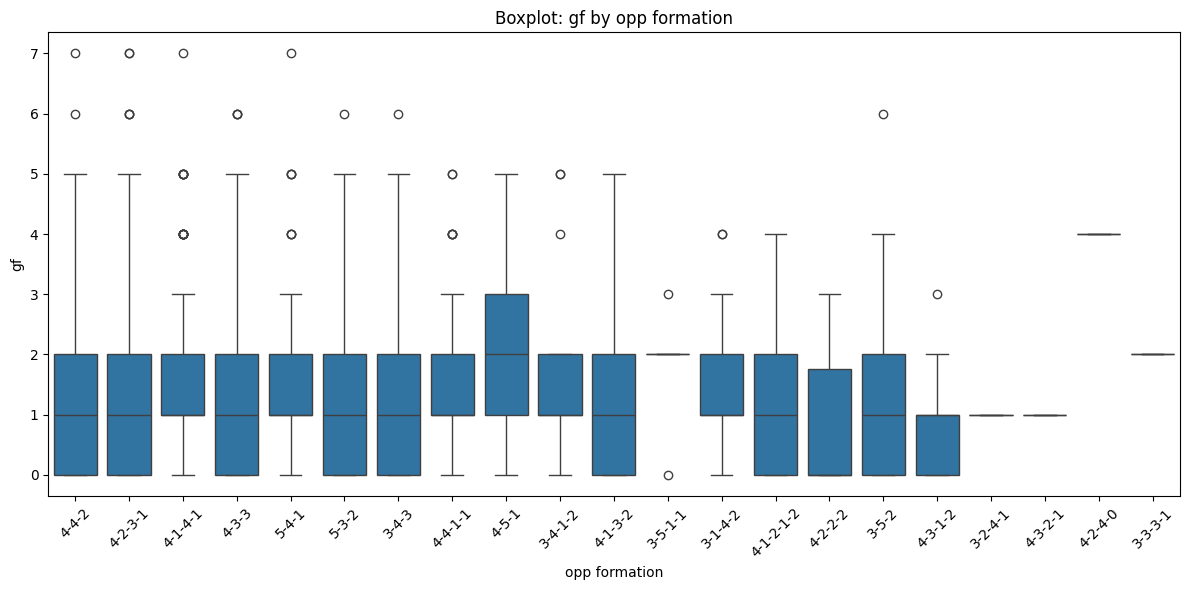

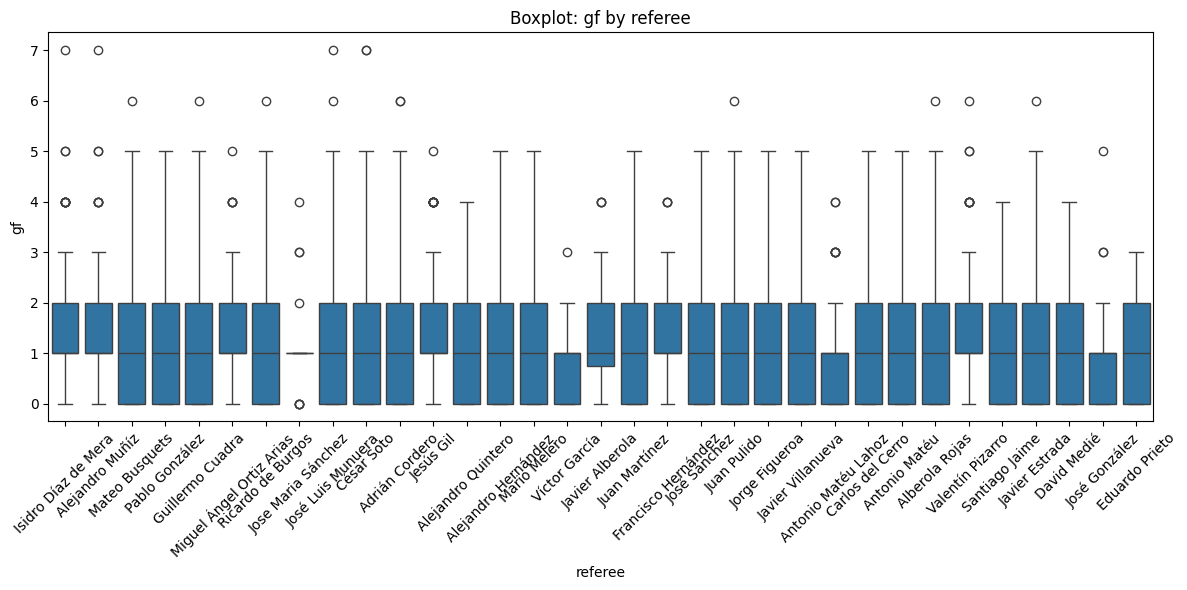

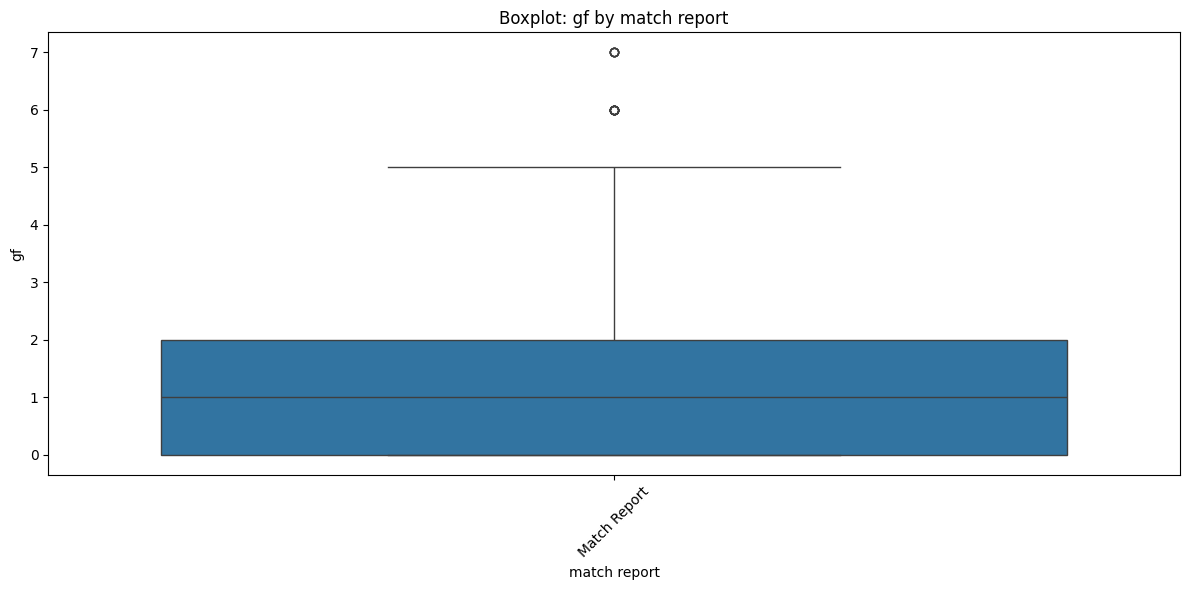

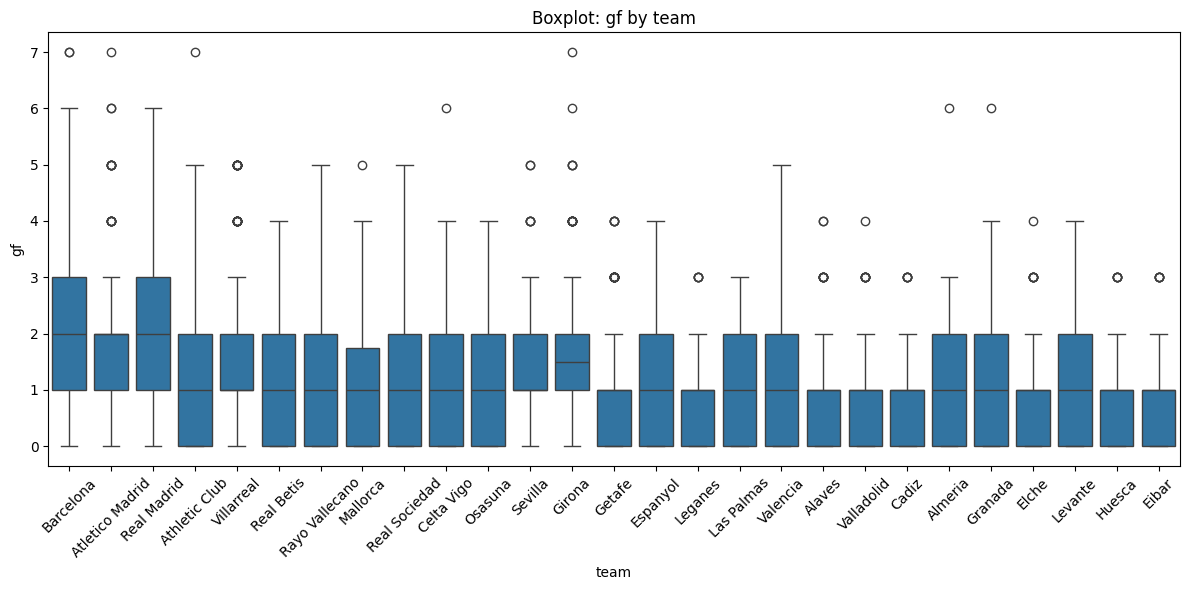

In [ ]:
target_col = 'gf'
categorical_cols = ['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'opponent',
                    'captain', 'formation', 'opp formation', 'referee', 'match report', 'team']

for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=col, y=target_col)
    plt.title(f"Boxplot: {target_col} by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


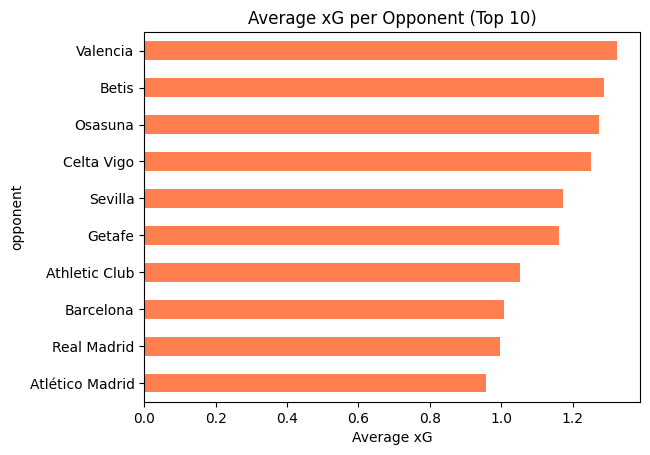

In [ ]:
# 4. Bar Plot: Average xG per Opponent (Top 10 opponents by frequency)
top_opponents = df['opponent'].value_counts().head(10).index
avg_xg = df[df['opponent'].isin(top_opponents)].groupby('opponent')['xg'].mean().sort_values()
plt.figure()
avg_xg.plot(kind='barh', color='coral')
plt.title("Average xG per Opponent (Top 10)")
plt.xlabel("Average xG")
plt.show()

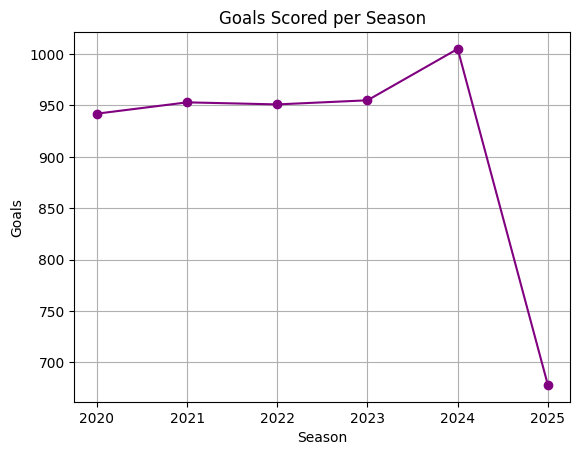

In [ ]:
# 5. Line Plot: Goals scored per season
season_goals = df.groupby('season')['gf'].sum()
plt.figure()
season_goals.plot(marker='o', linestyle='-', color='purple')
plt.title("Goals Scored per Season")
plt.xlabel("Season")
plt.ylabel("Goals")
plt.grid(True)
plt.show()

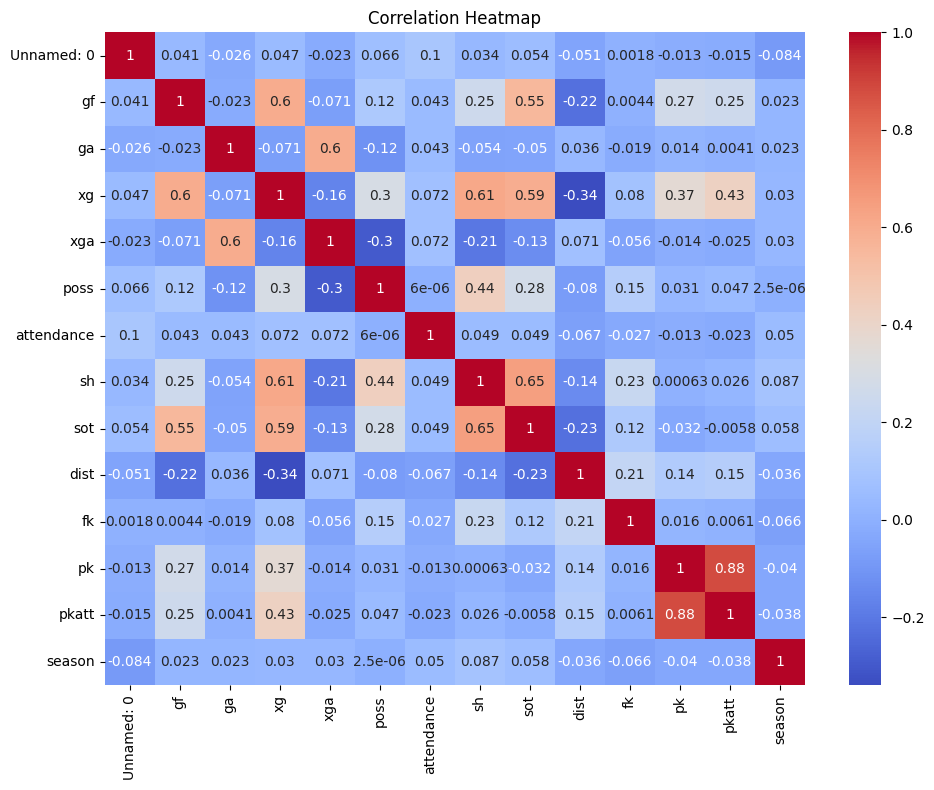

In [ ]:
# 4. Heatmap: Correlation between numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

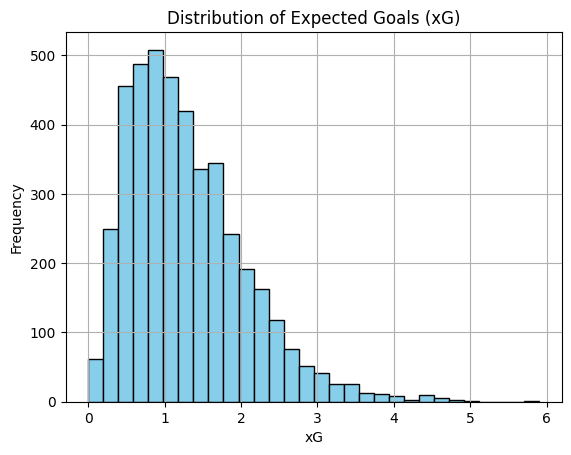

In [ ]:
# 1. Histogram of 'xg' (Expected Goals)
plt.figure()
df['xg'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Expected Goals (xG)")
plt.xlabel("xG")
plt.ylabel("Frequency")
plt.show()

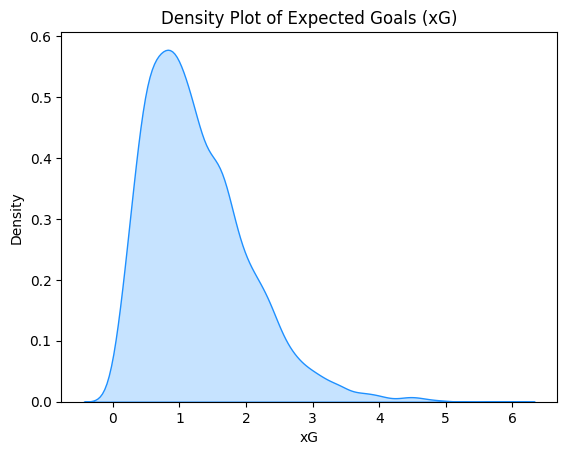

In [ ]:
# 7. Density Plot for 'xg'
plt.figure()
sns.kdeplot(df['xg'].dropna(), fill=True, color='dodgerblue')
plt.title("Density Plot of Expected Goals (xG)")
plt.xlabel("xG")
plt.show()

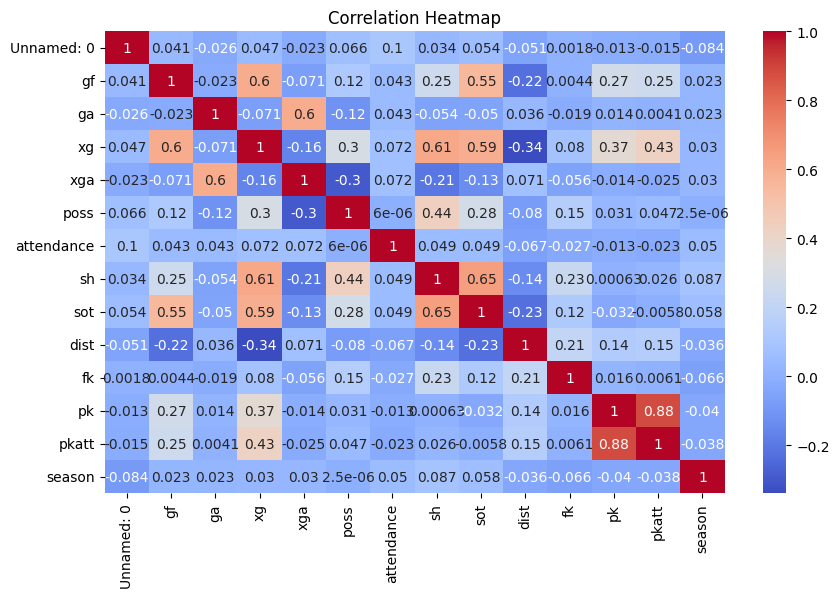

In [ ]:
# 6. Heatmap: Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

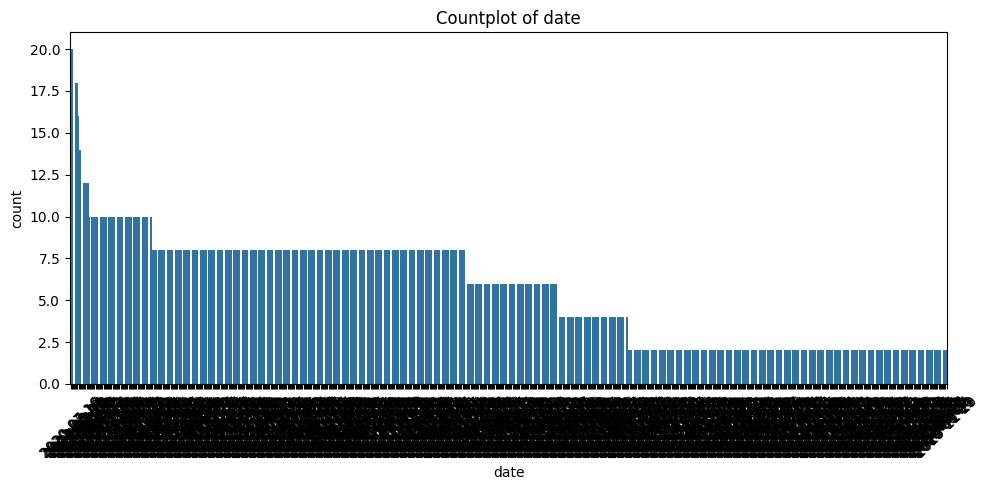

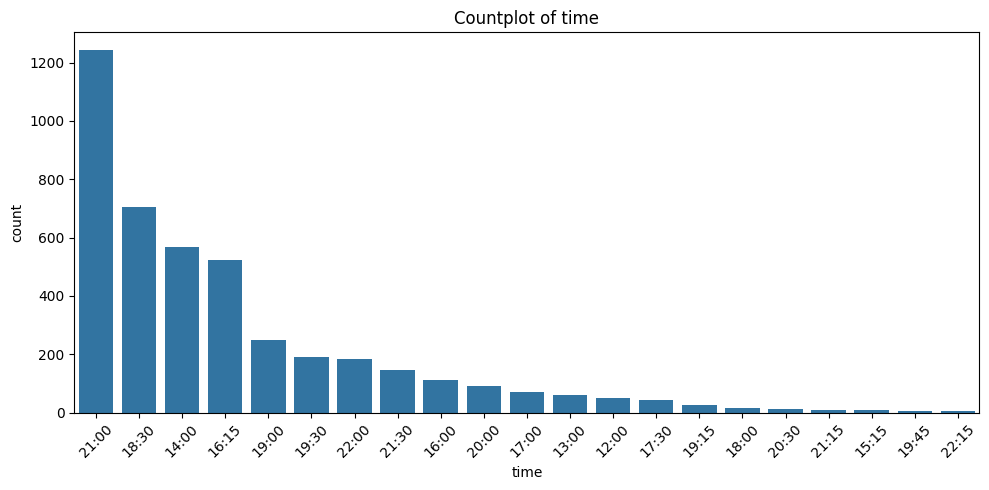

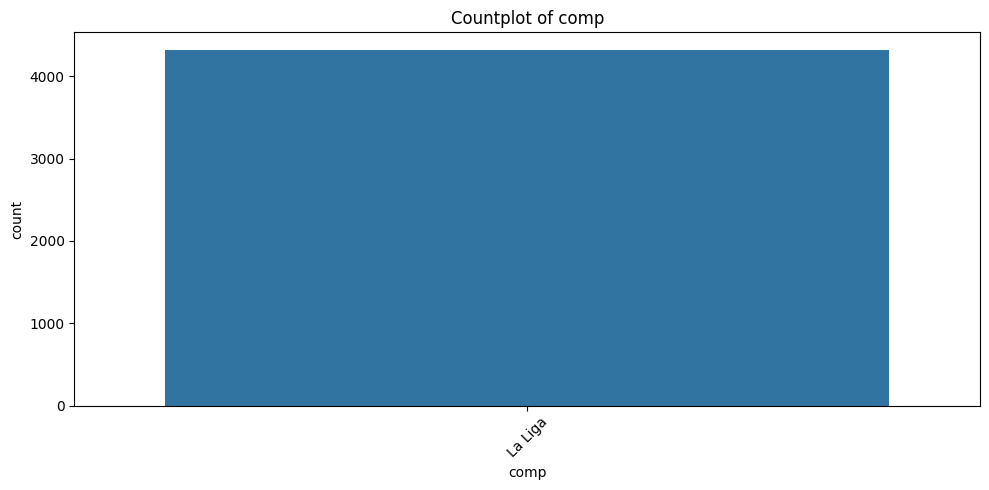

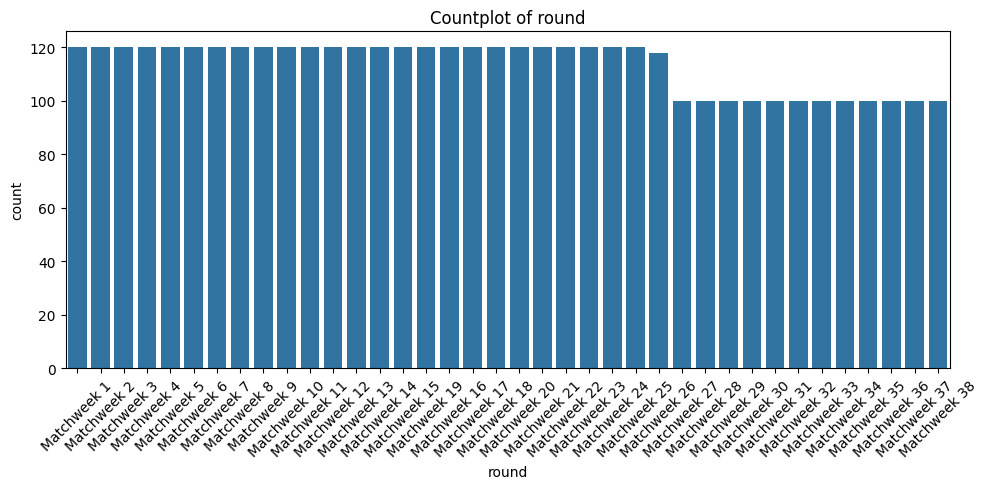

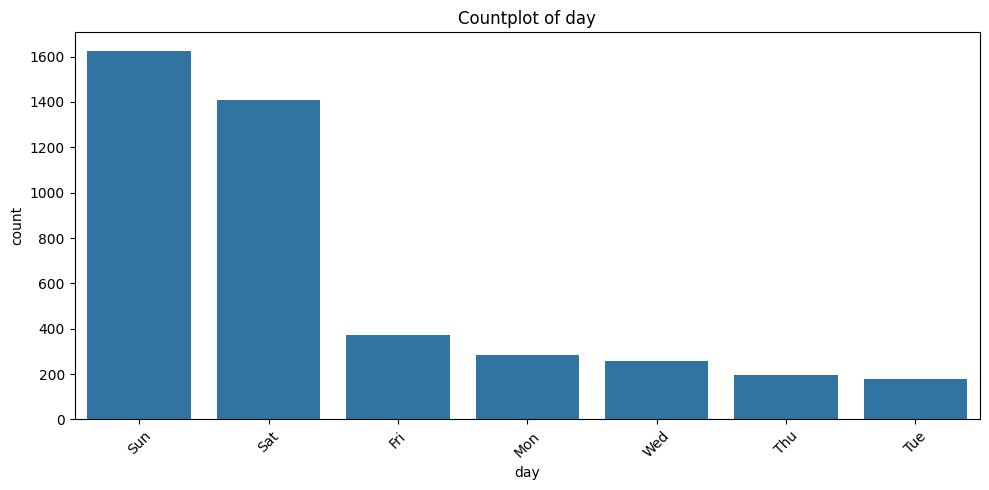

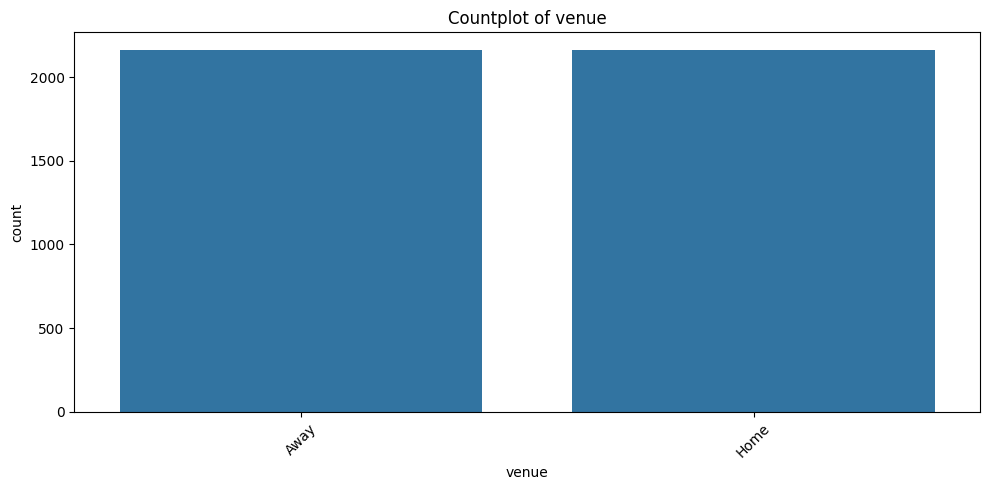

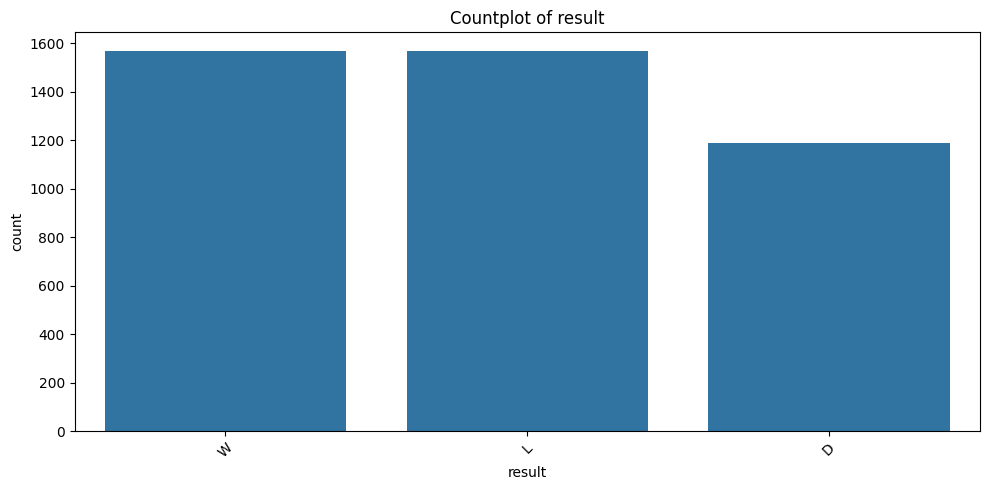

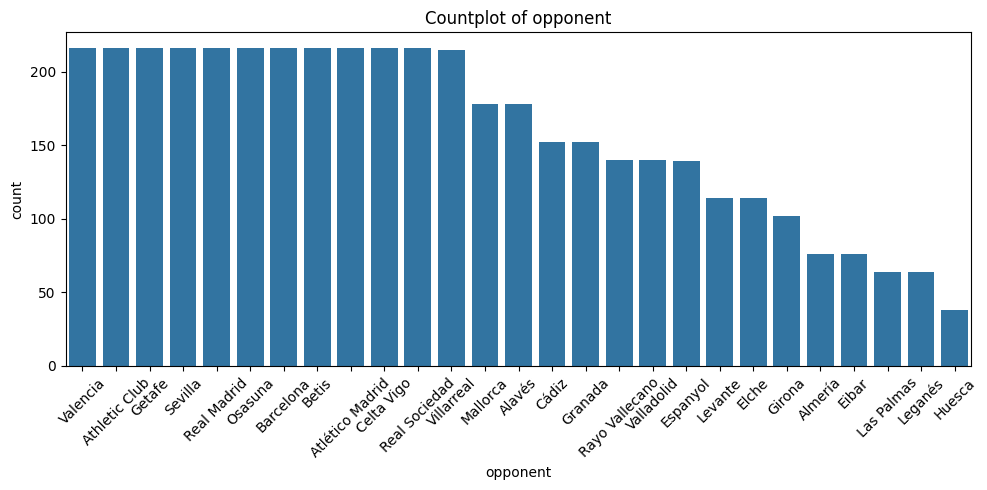

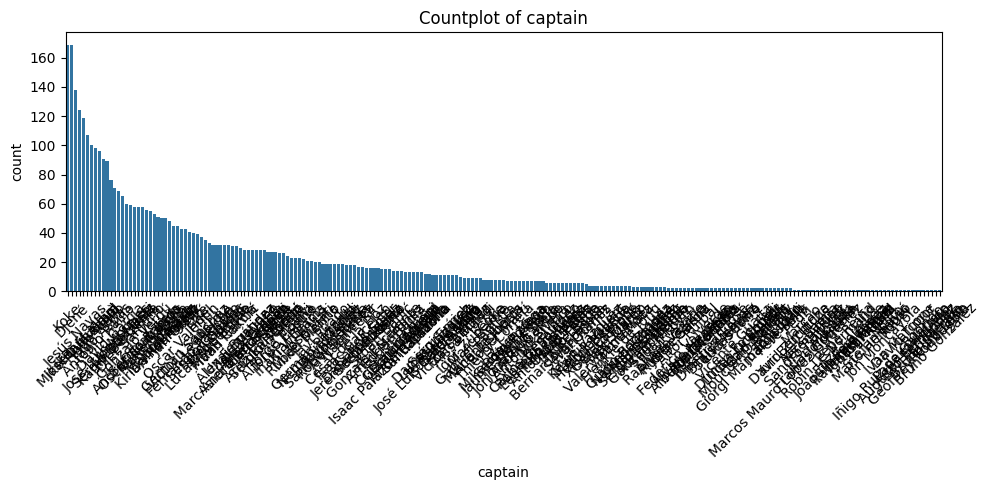

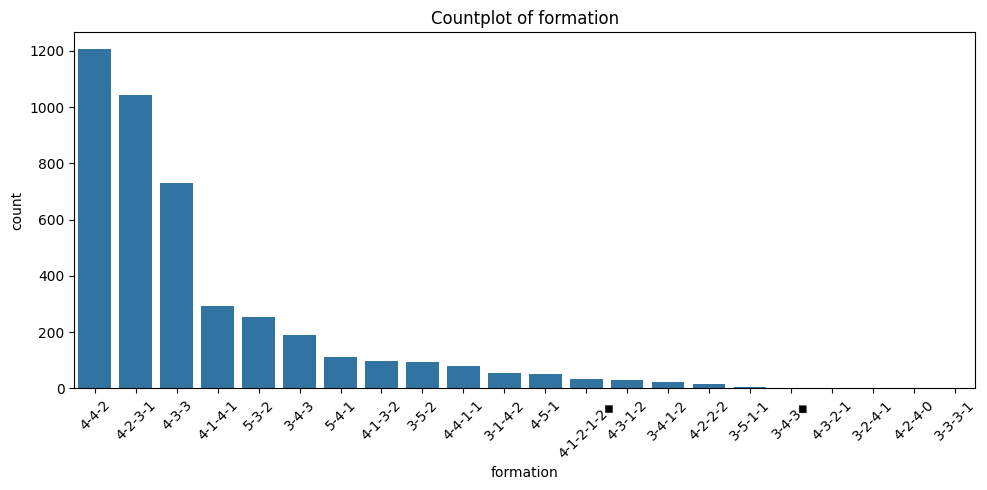

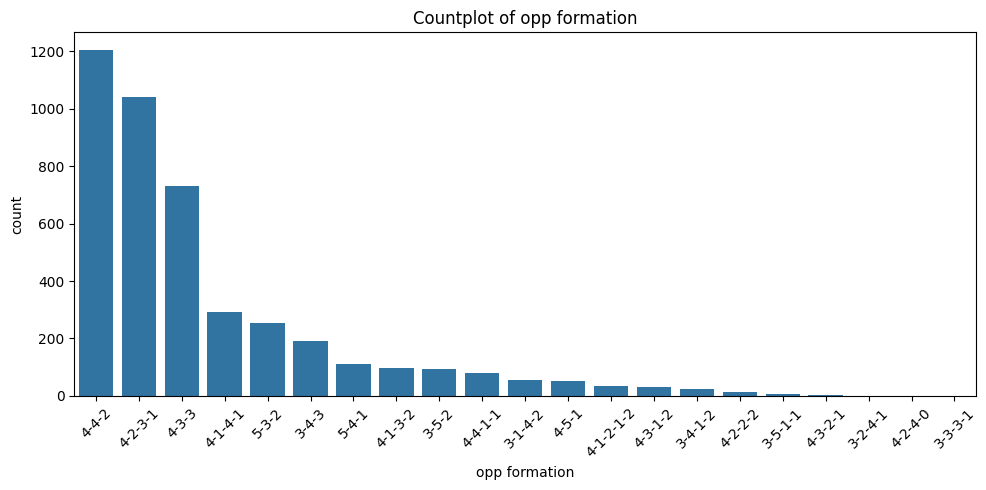

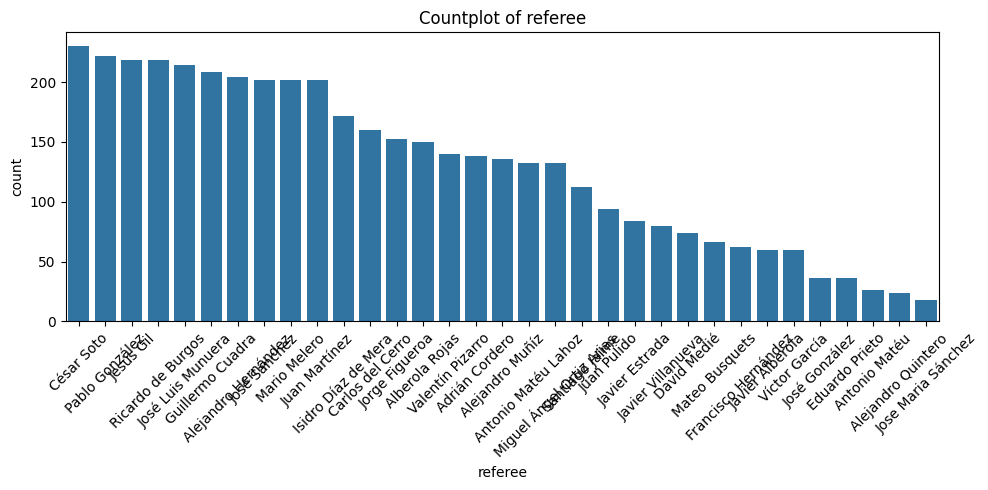

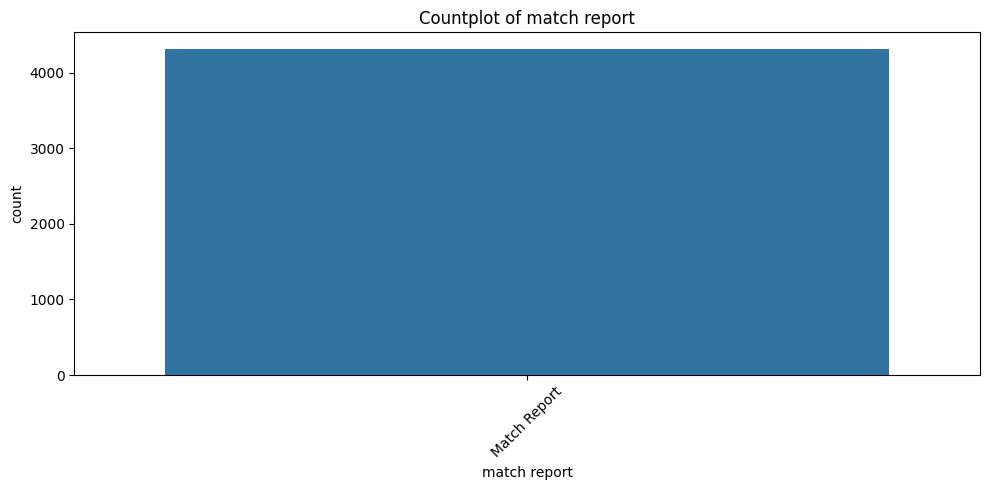

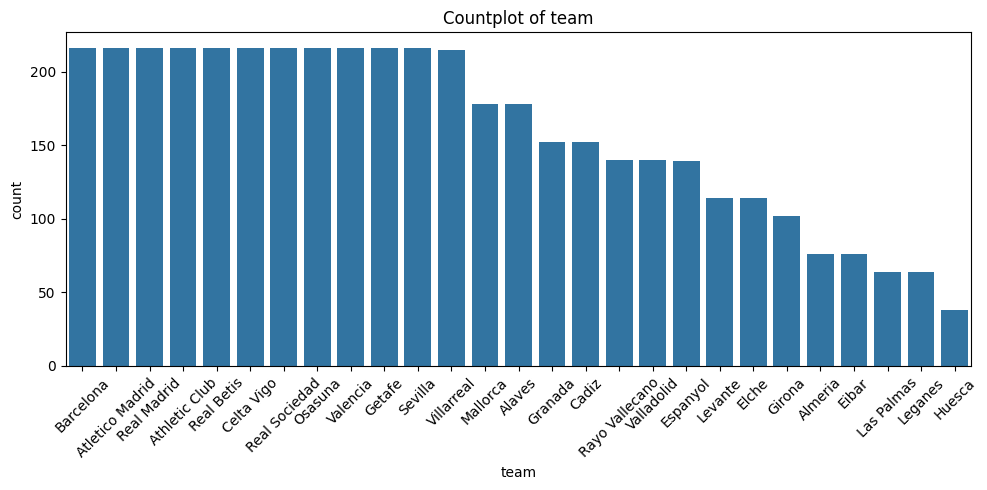

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Countplot of {col}")
    plt.tight_layout()
    plt.show()

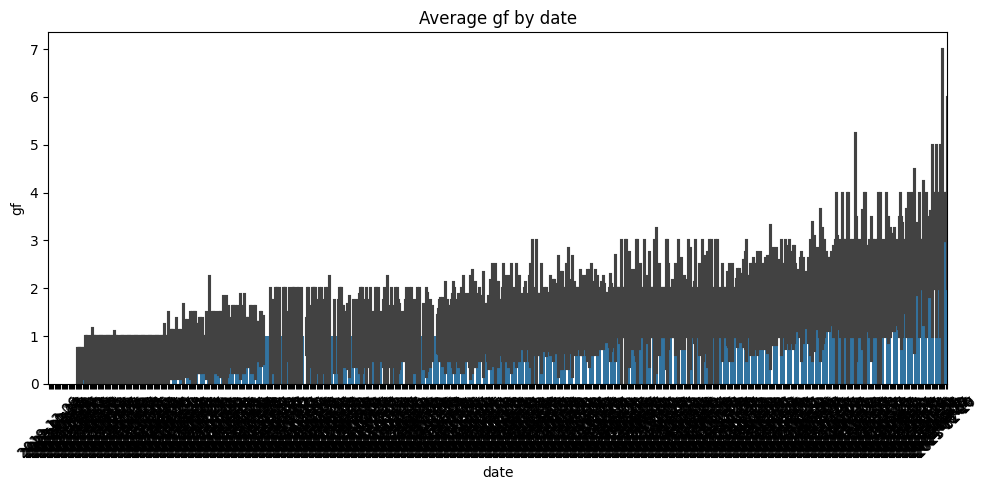

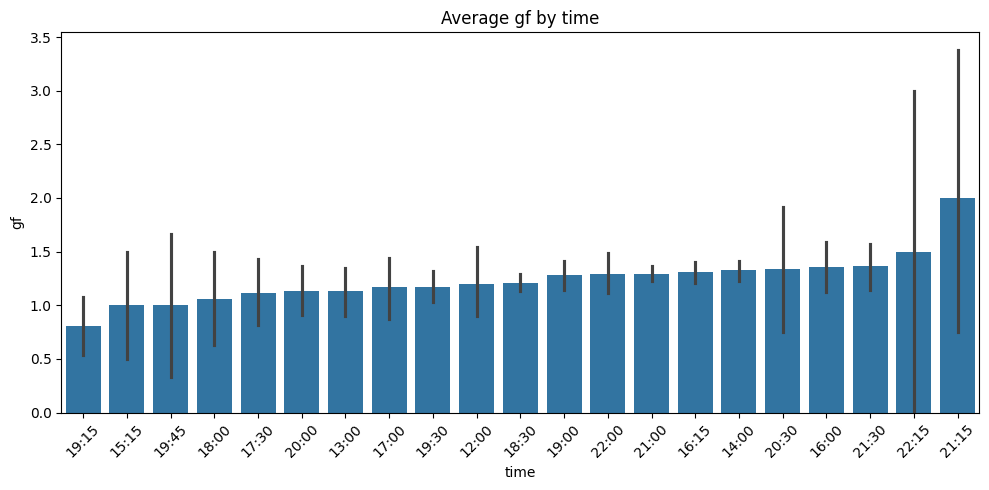

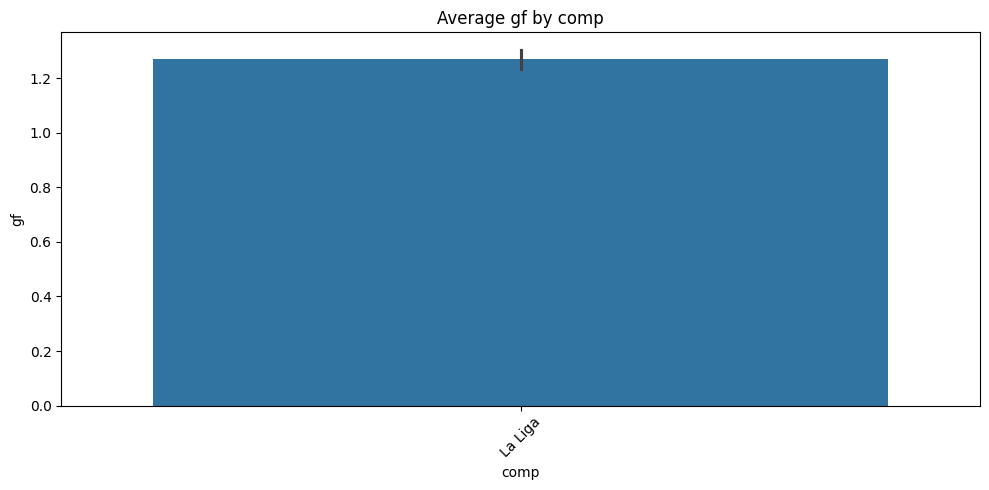

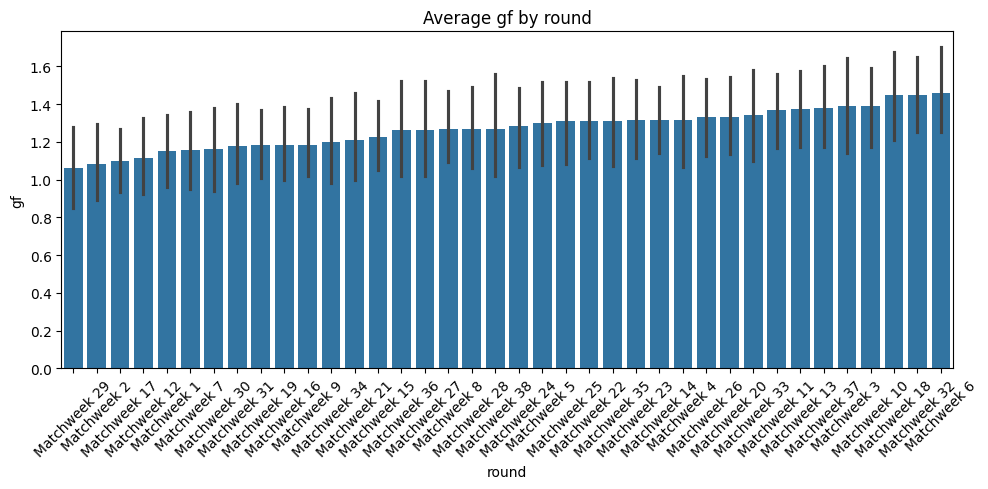

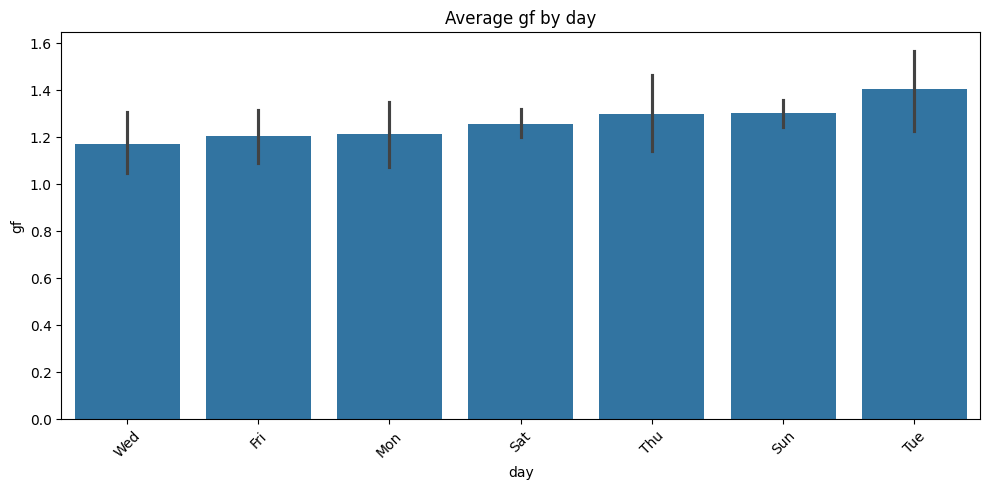

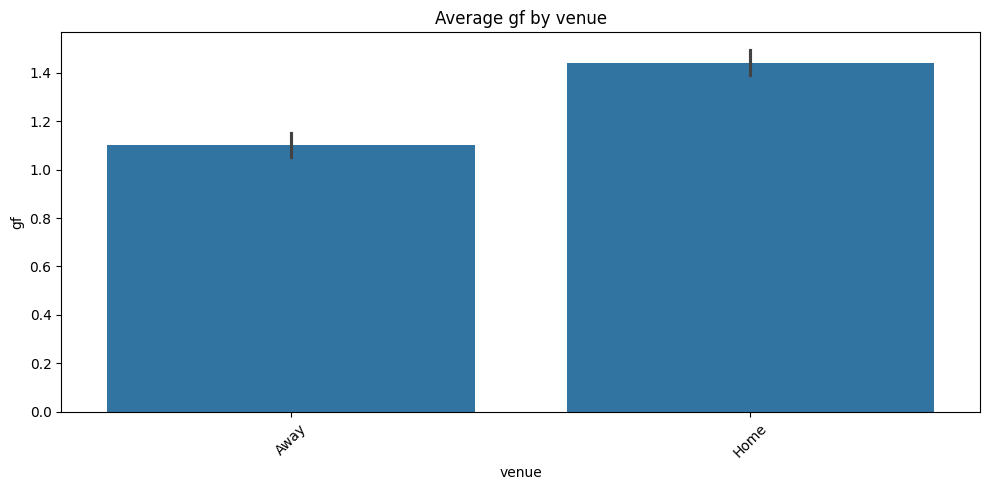

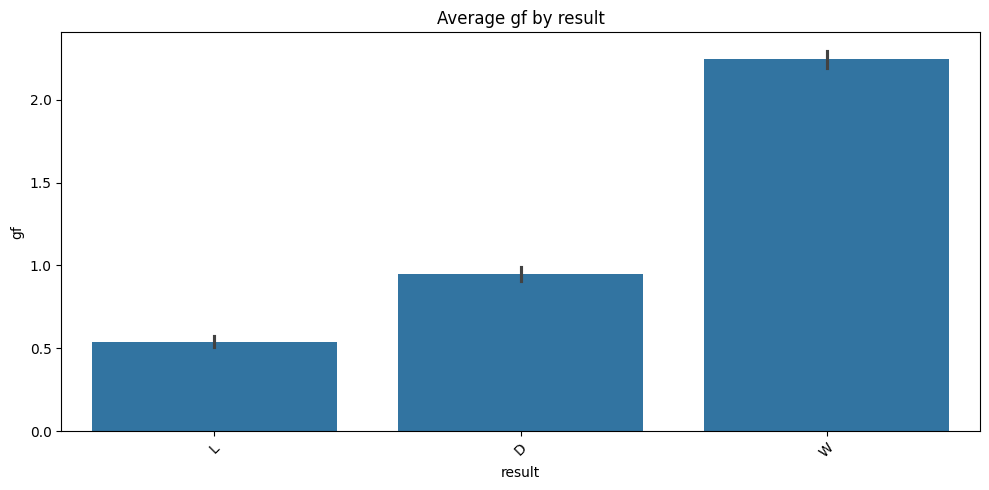

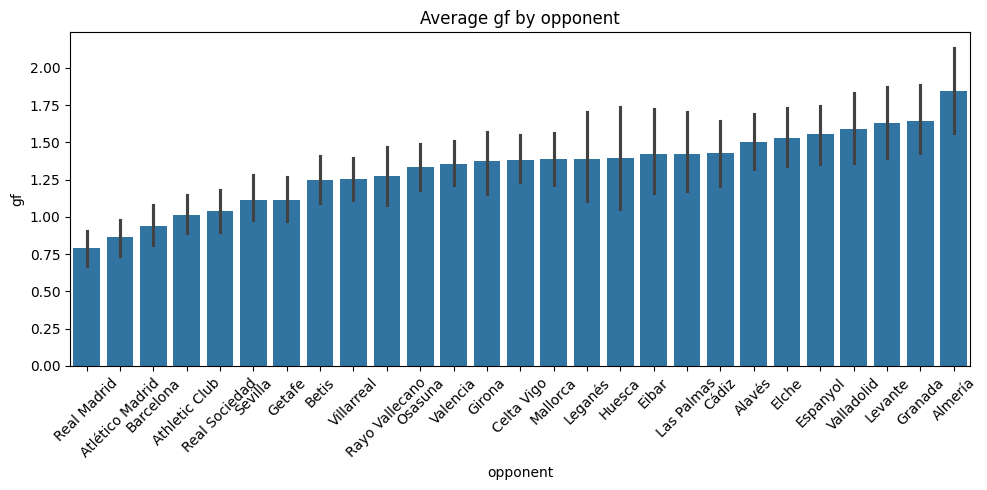

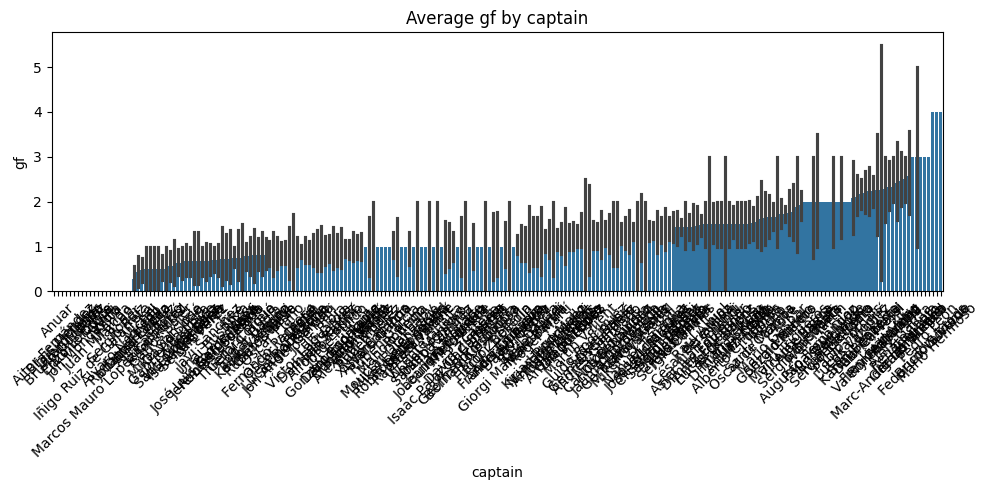

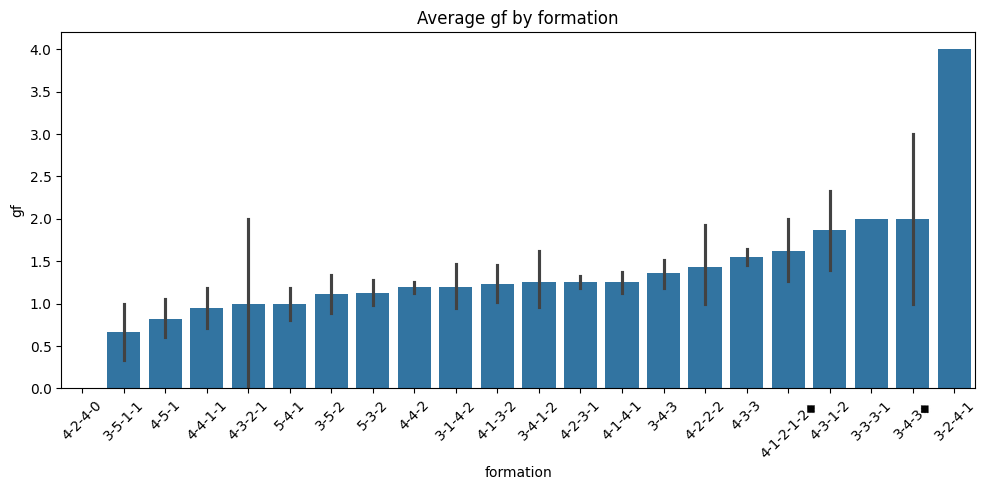

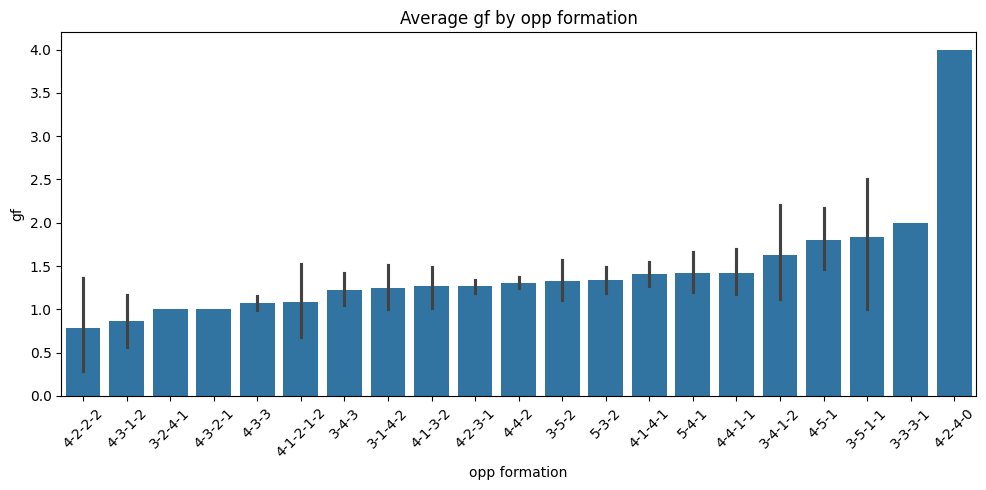

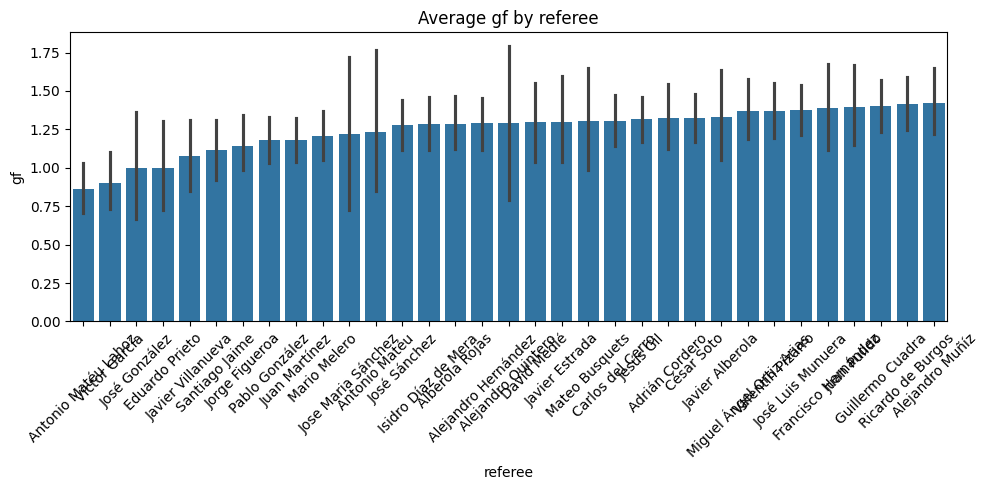

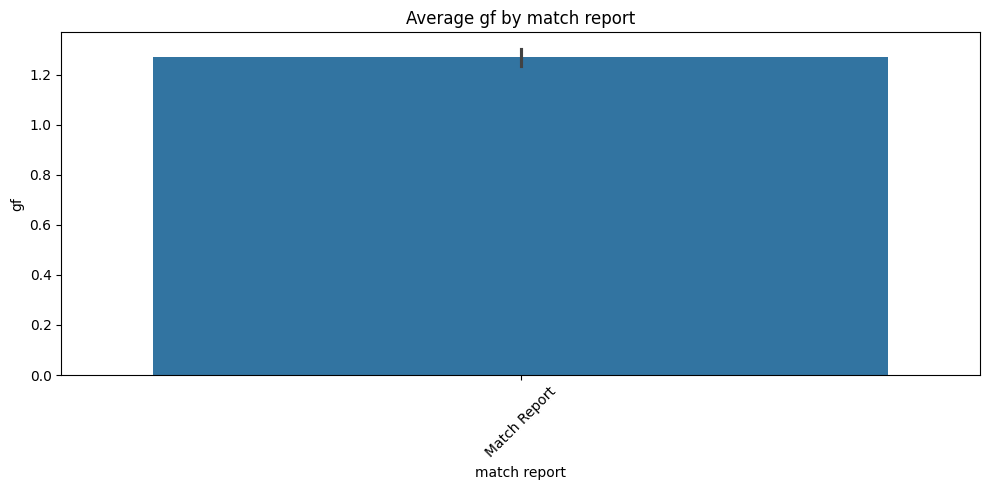

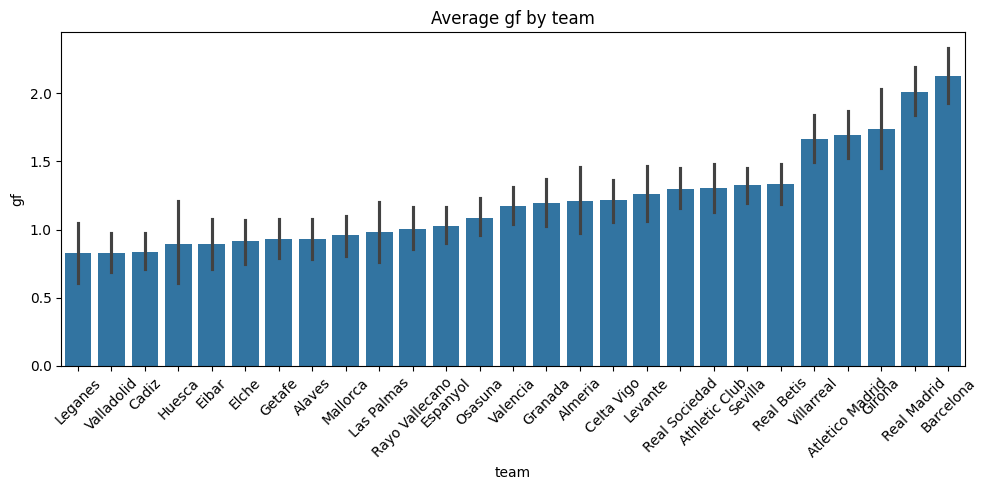

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    order = df.groupby(col)[target_col].mean().sort_values().index
    sns.barplot(data=df, x=col, y=target_col, order=order)
    plt.xticks(rotation=45)
    plt.title(f"Average {target_col} by {col}")
    plt.tight_layout()
    plt.show()


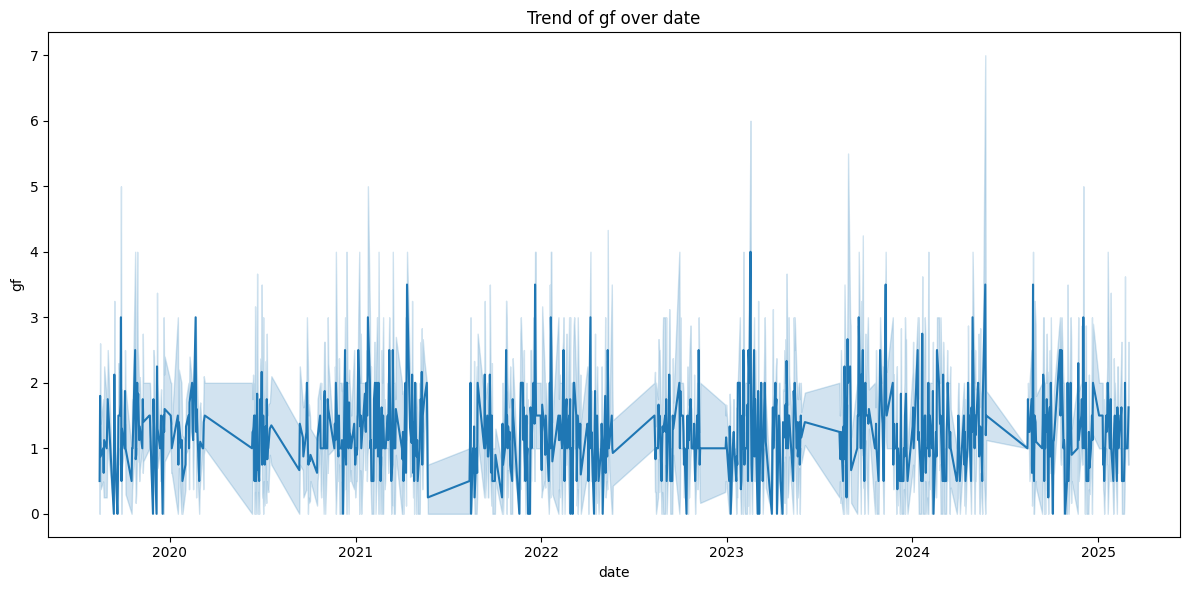

In [ ]:
# Example: average target by date (if date is datetime)
df['date'] = pd.to_datetime(df['date'])

time_col = 'date'
df_sorted = df.sort_values(time_col)
plt.figure(figsize=(12,6))
sns.lineplot(data=df_sorted, x=time_col, y=target_col)
plt.title(f"Trend of {target_col} over {time_col}")
plt.tight_layout()
plt.show()

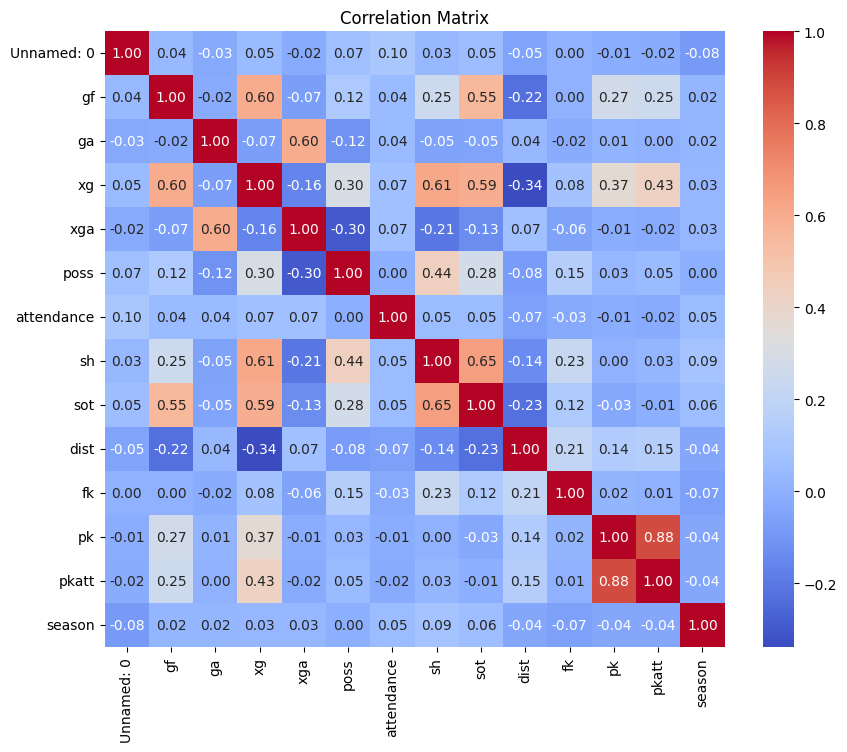

In [ ]:
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()

plt.title("Correlation Matrix")

# Set specific value (both [row, col] and [col, row]) to NaN
if corr.loc['poss', 'xg'] == 0.30:
    corr.loc['poss', 'xg'] = np.nan
    corr.loc['xg', 'poss'] = np.nan  # make symmetric

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.show()

Correlation between poss and xg: 0.2959984261590203


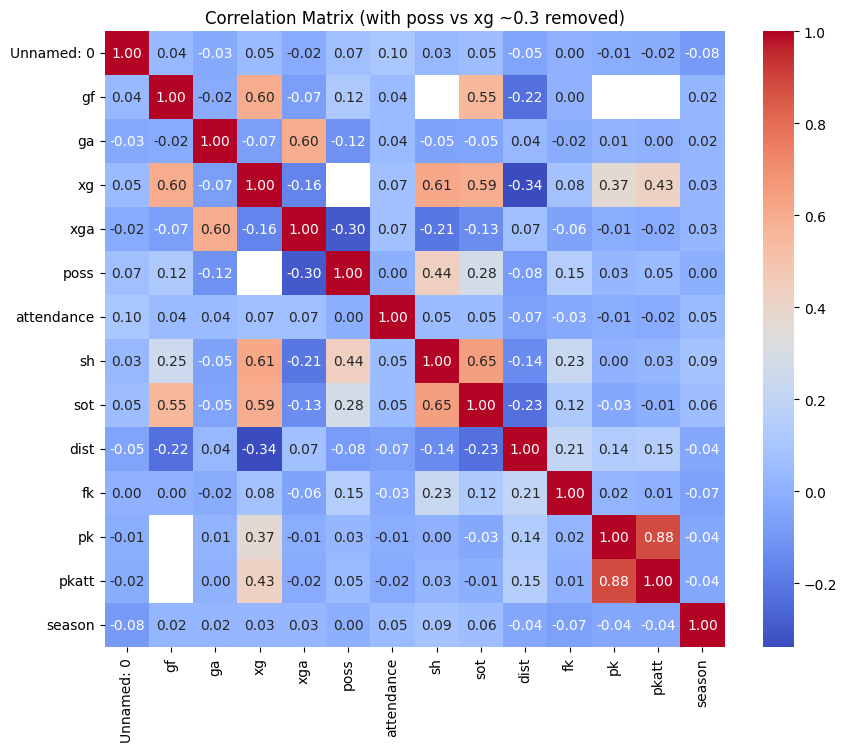

In [ ]:
plt.figure(figsize=(10, 8))

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Check actual value (optional debug)
print("Correlation between poss and xg:", corr.loc['poss', 'xg'])

# Replace the value with NaN if it's approximately 0.3
if np.isclose(corr.loc['poss', 'xg'], 0.3, atol=0.01):  # or change atol to 0.001 for stricter match
    corr.loc['poss', 'xg'] = np.nan
    corr.loc['xg', 'poss'] = np.nan  # Make symmetric

if np.isclose(corr.loc['gf', 'sh'], 0.25, atol=0.01):  # or change atol to 0.001 for stricter match
    corr.loc['gf', 'sh'] = np.nan
    corr.loc['gf', 'sh'] = np.nan

if np.isclose(corr.loc['gf', 'pkatt'], 0.25, atol=0.01):  # or change atol to 0.001 for stricter match
    corr.loc['gf', 'pkatt'] = np.nan
    corr.loc['gf', 'pkatt'] = np.nan

if np.isclose(corr.loc['gf', 'pk'], 0.27, atol=0.01):  # or change atol to 0.001 for stricter match
    corr.loc['gf', 'pk'] = np.nan
    corr.loc['gf', 'pk'] = np.nan

if np.isclose(corr.loc['pk', 'gf'], 0.27, atol=0.01):  # or change atol to 0.001 for stricter match
    corr.loc['pk', 'gf'] = np.nan
    corr.loc['pk', 'gf'] = np.nan

if np.isclose(corr.loc['pkatt', 'gf'], 0.25, atol=0.01):  # or change atol to 0.001 for stricter match
    corr.loc['pkatt', 'gf'] = np.nan
    corr.loc['pkatt', 'gf'] = np.nan
# Plot heatmap with NaNs (blank)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=corr.isnull())

plt.title("Correlation Matrix (with poss vs xg ~0.3 removed)")
plt.show()

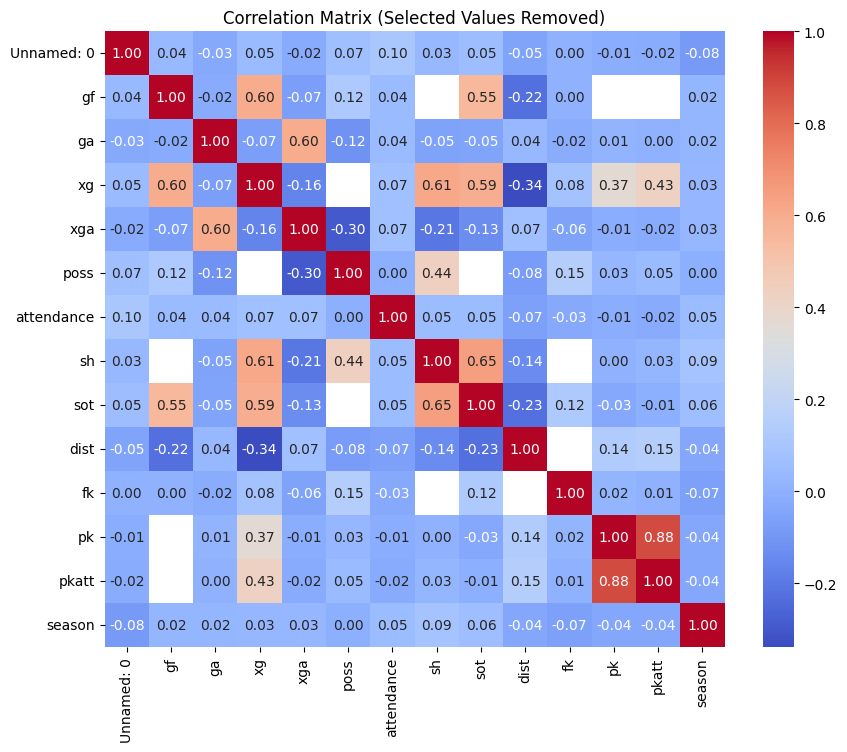

In [ ]:
plt.figure(figsize=(10, 8))

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Define correlations you want to remove:
# Format: (row, column, target_value)
to_remove = [
    ('poss', 'xg', 0.30),
    ('gf', 'sh', 0.25),
    ('gf', 'pkatt', 0.25),
    ('gf', 'pk', 0.27),
    ('pk', 'gf', 0.27),
    ('pkatt', 'gf', 0.25),
    ('fk','sh',0.23),
    ('dist','fk',0.21),
    ('sot','poss',0.28),
]

# Tolerance for "approximately equal"
tolerance = 0.01

# Loop through and remove the values
for row, col, val in to_remove:
    if np.isclose(corr.loc[row, col], val, atol=tolerance):
        corr.loc[row, col] = np.nan
    if np.isclose(corr.loc[col, row], val, atol=tolerance):  # symmetric
        corr.loc[col, row] = np.nan

# Plot heatmap with NaNs masked
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=corr.isnull())
plt.title("Correlation Matrix (Selected Values Removed)")
plt.show()


/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


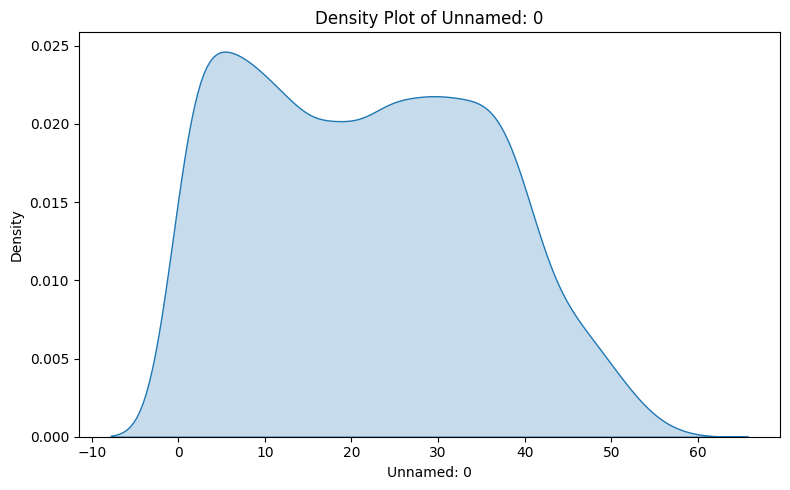

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


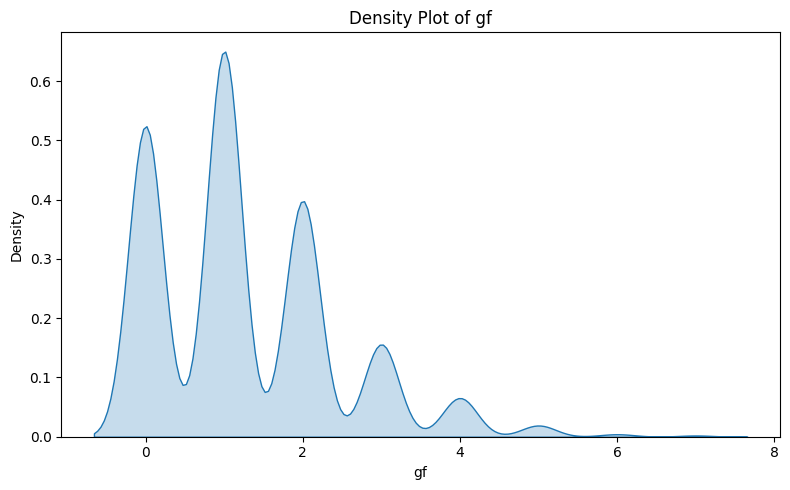

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


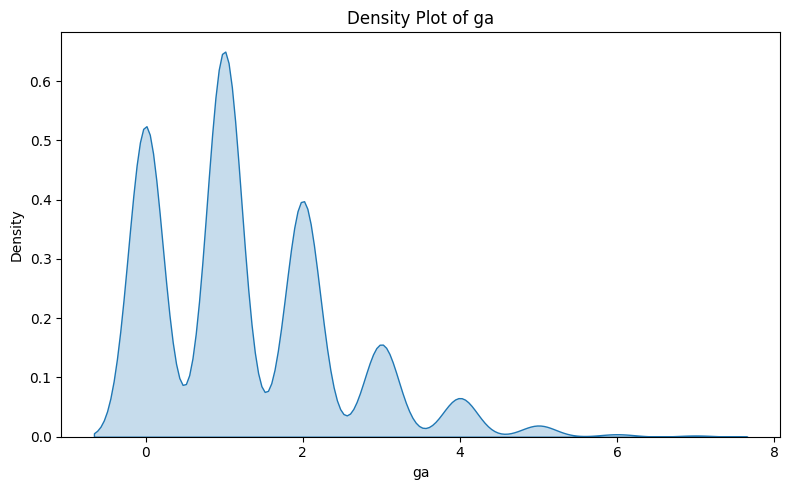

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


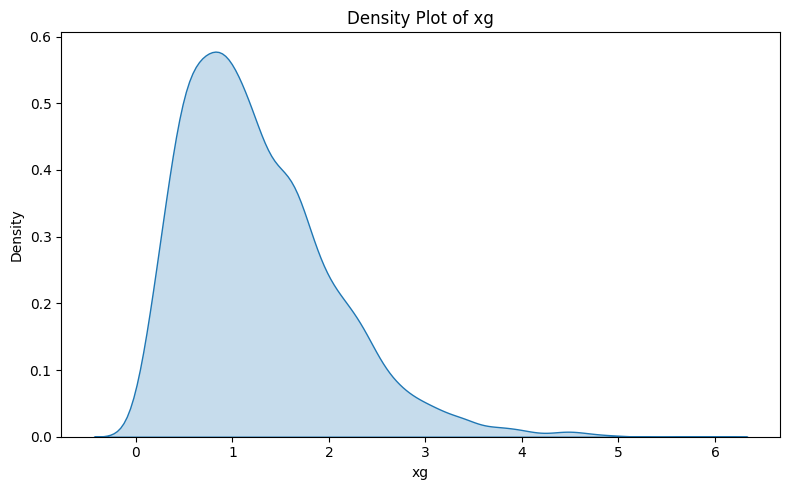

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


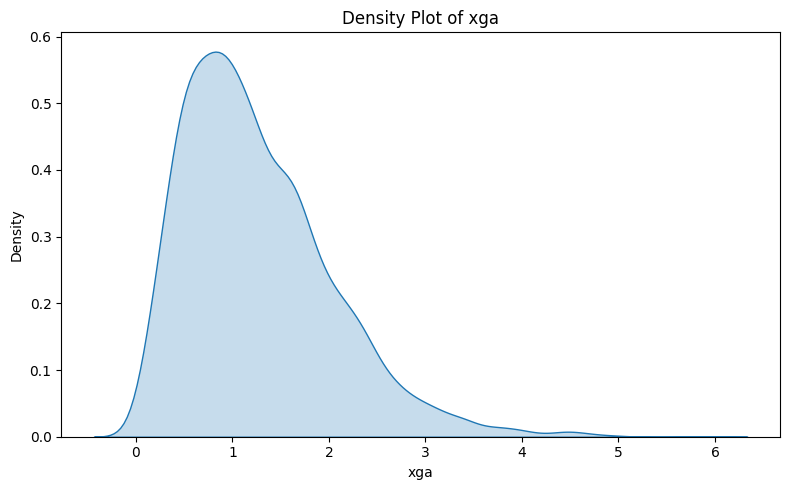

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


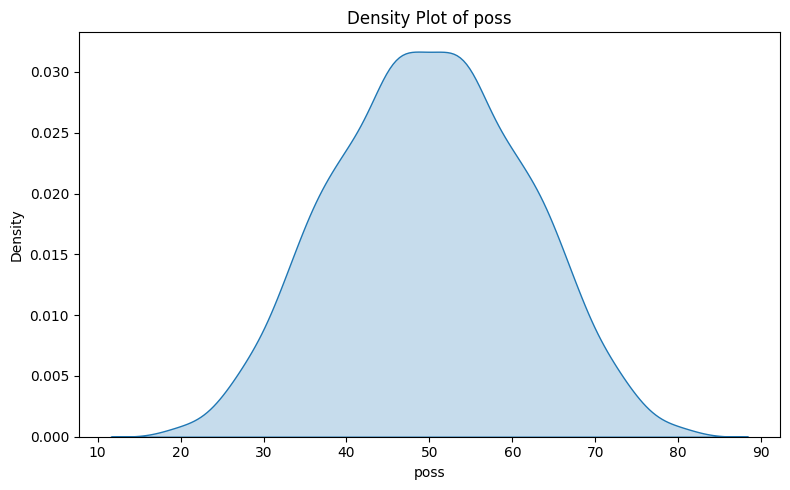

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


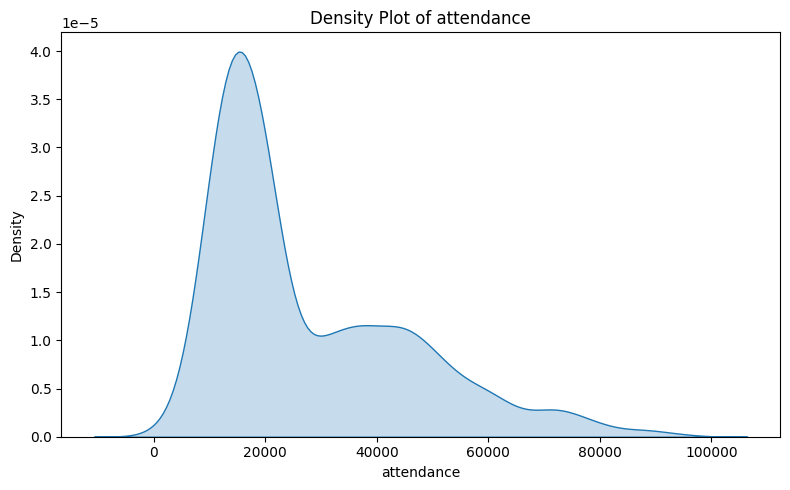

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


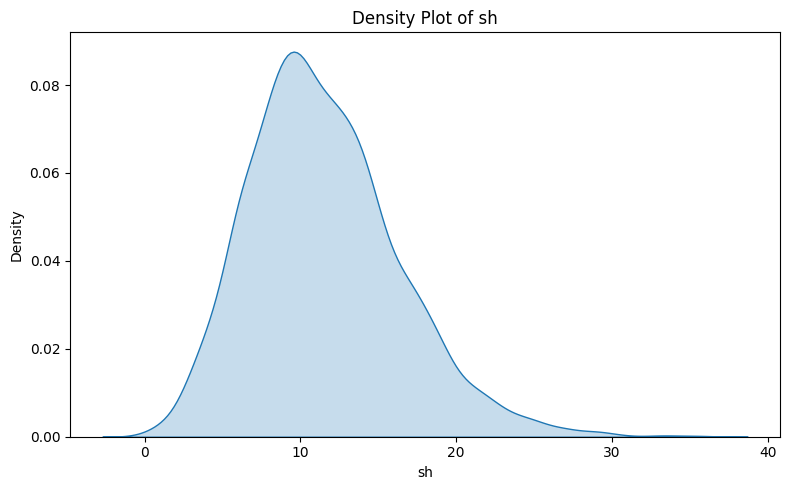

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


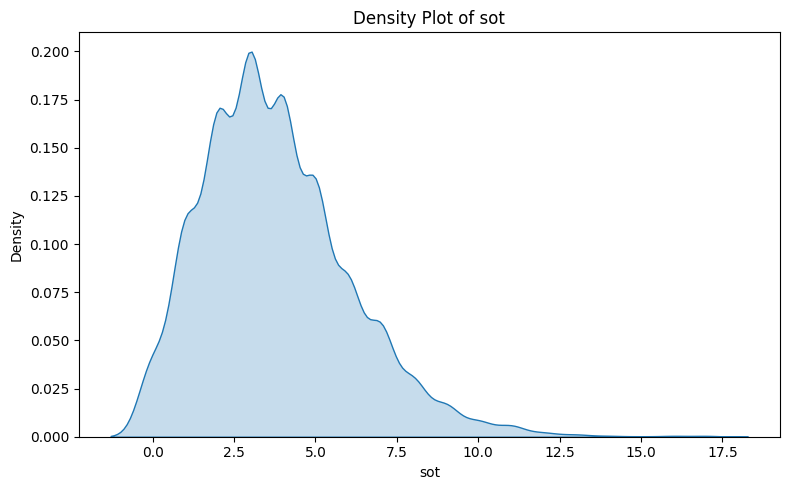

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


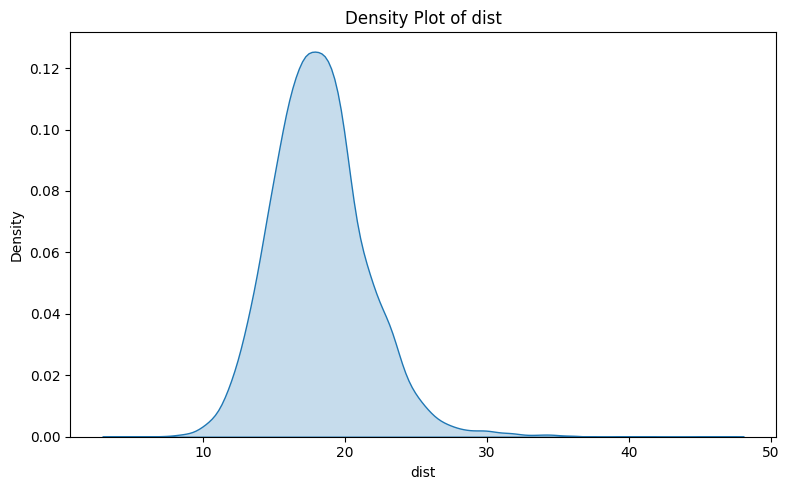

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


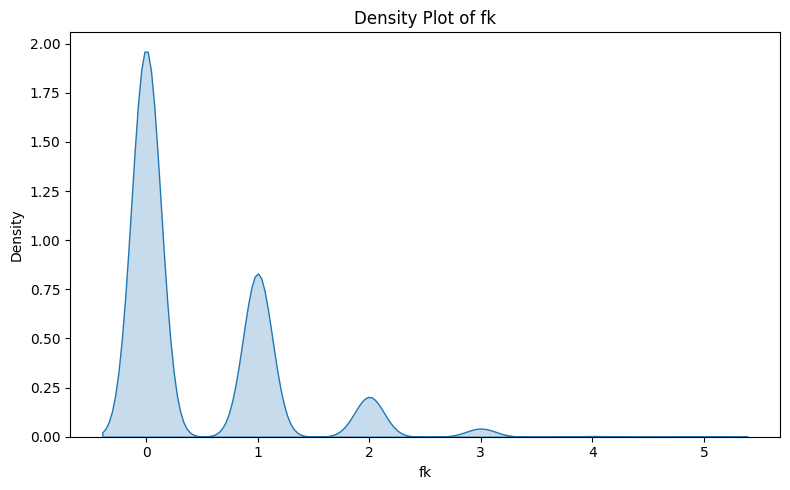

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


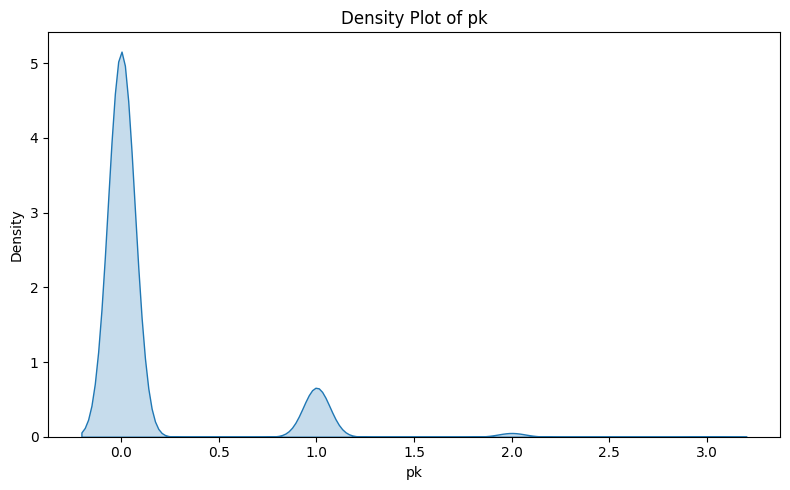

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


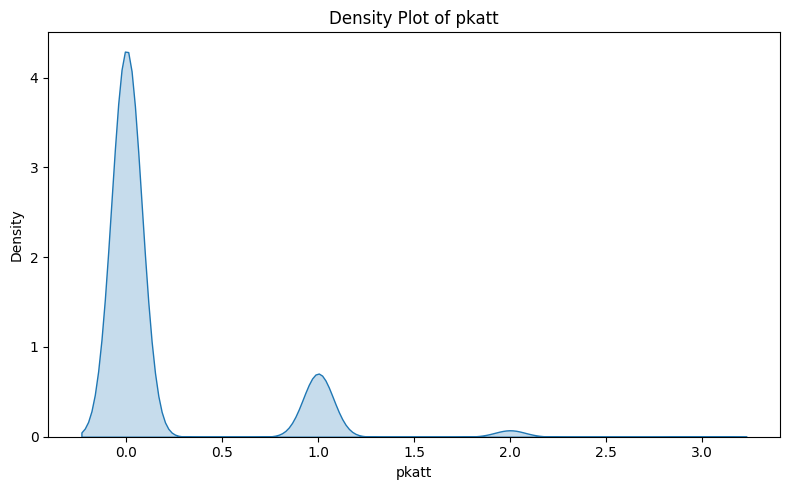

/tmp/ipython-input-36-1172360527.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


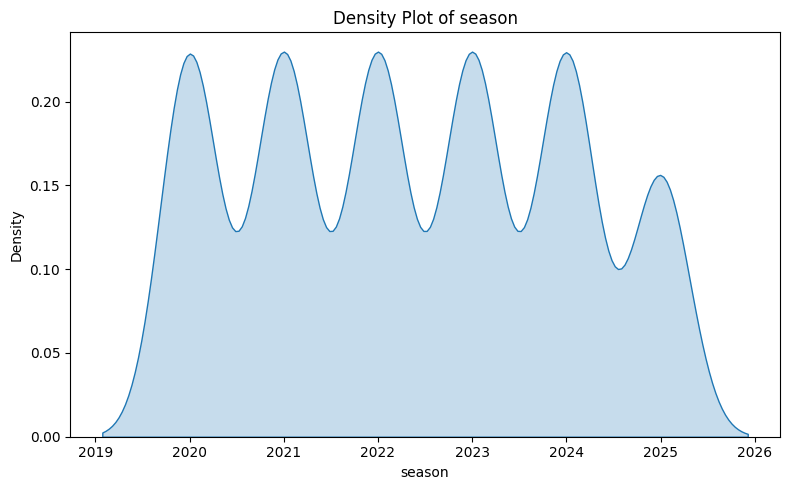

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8,5))
    sns.kdeplot(df[col], shade=True)
    plt.title(f"Density Plot of {col}")
    plt.tight_layout()
    plt.show()

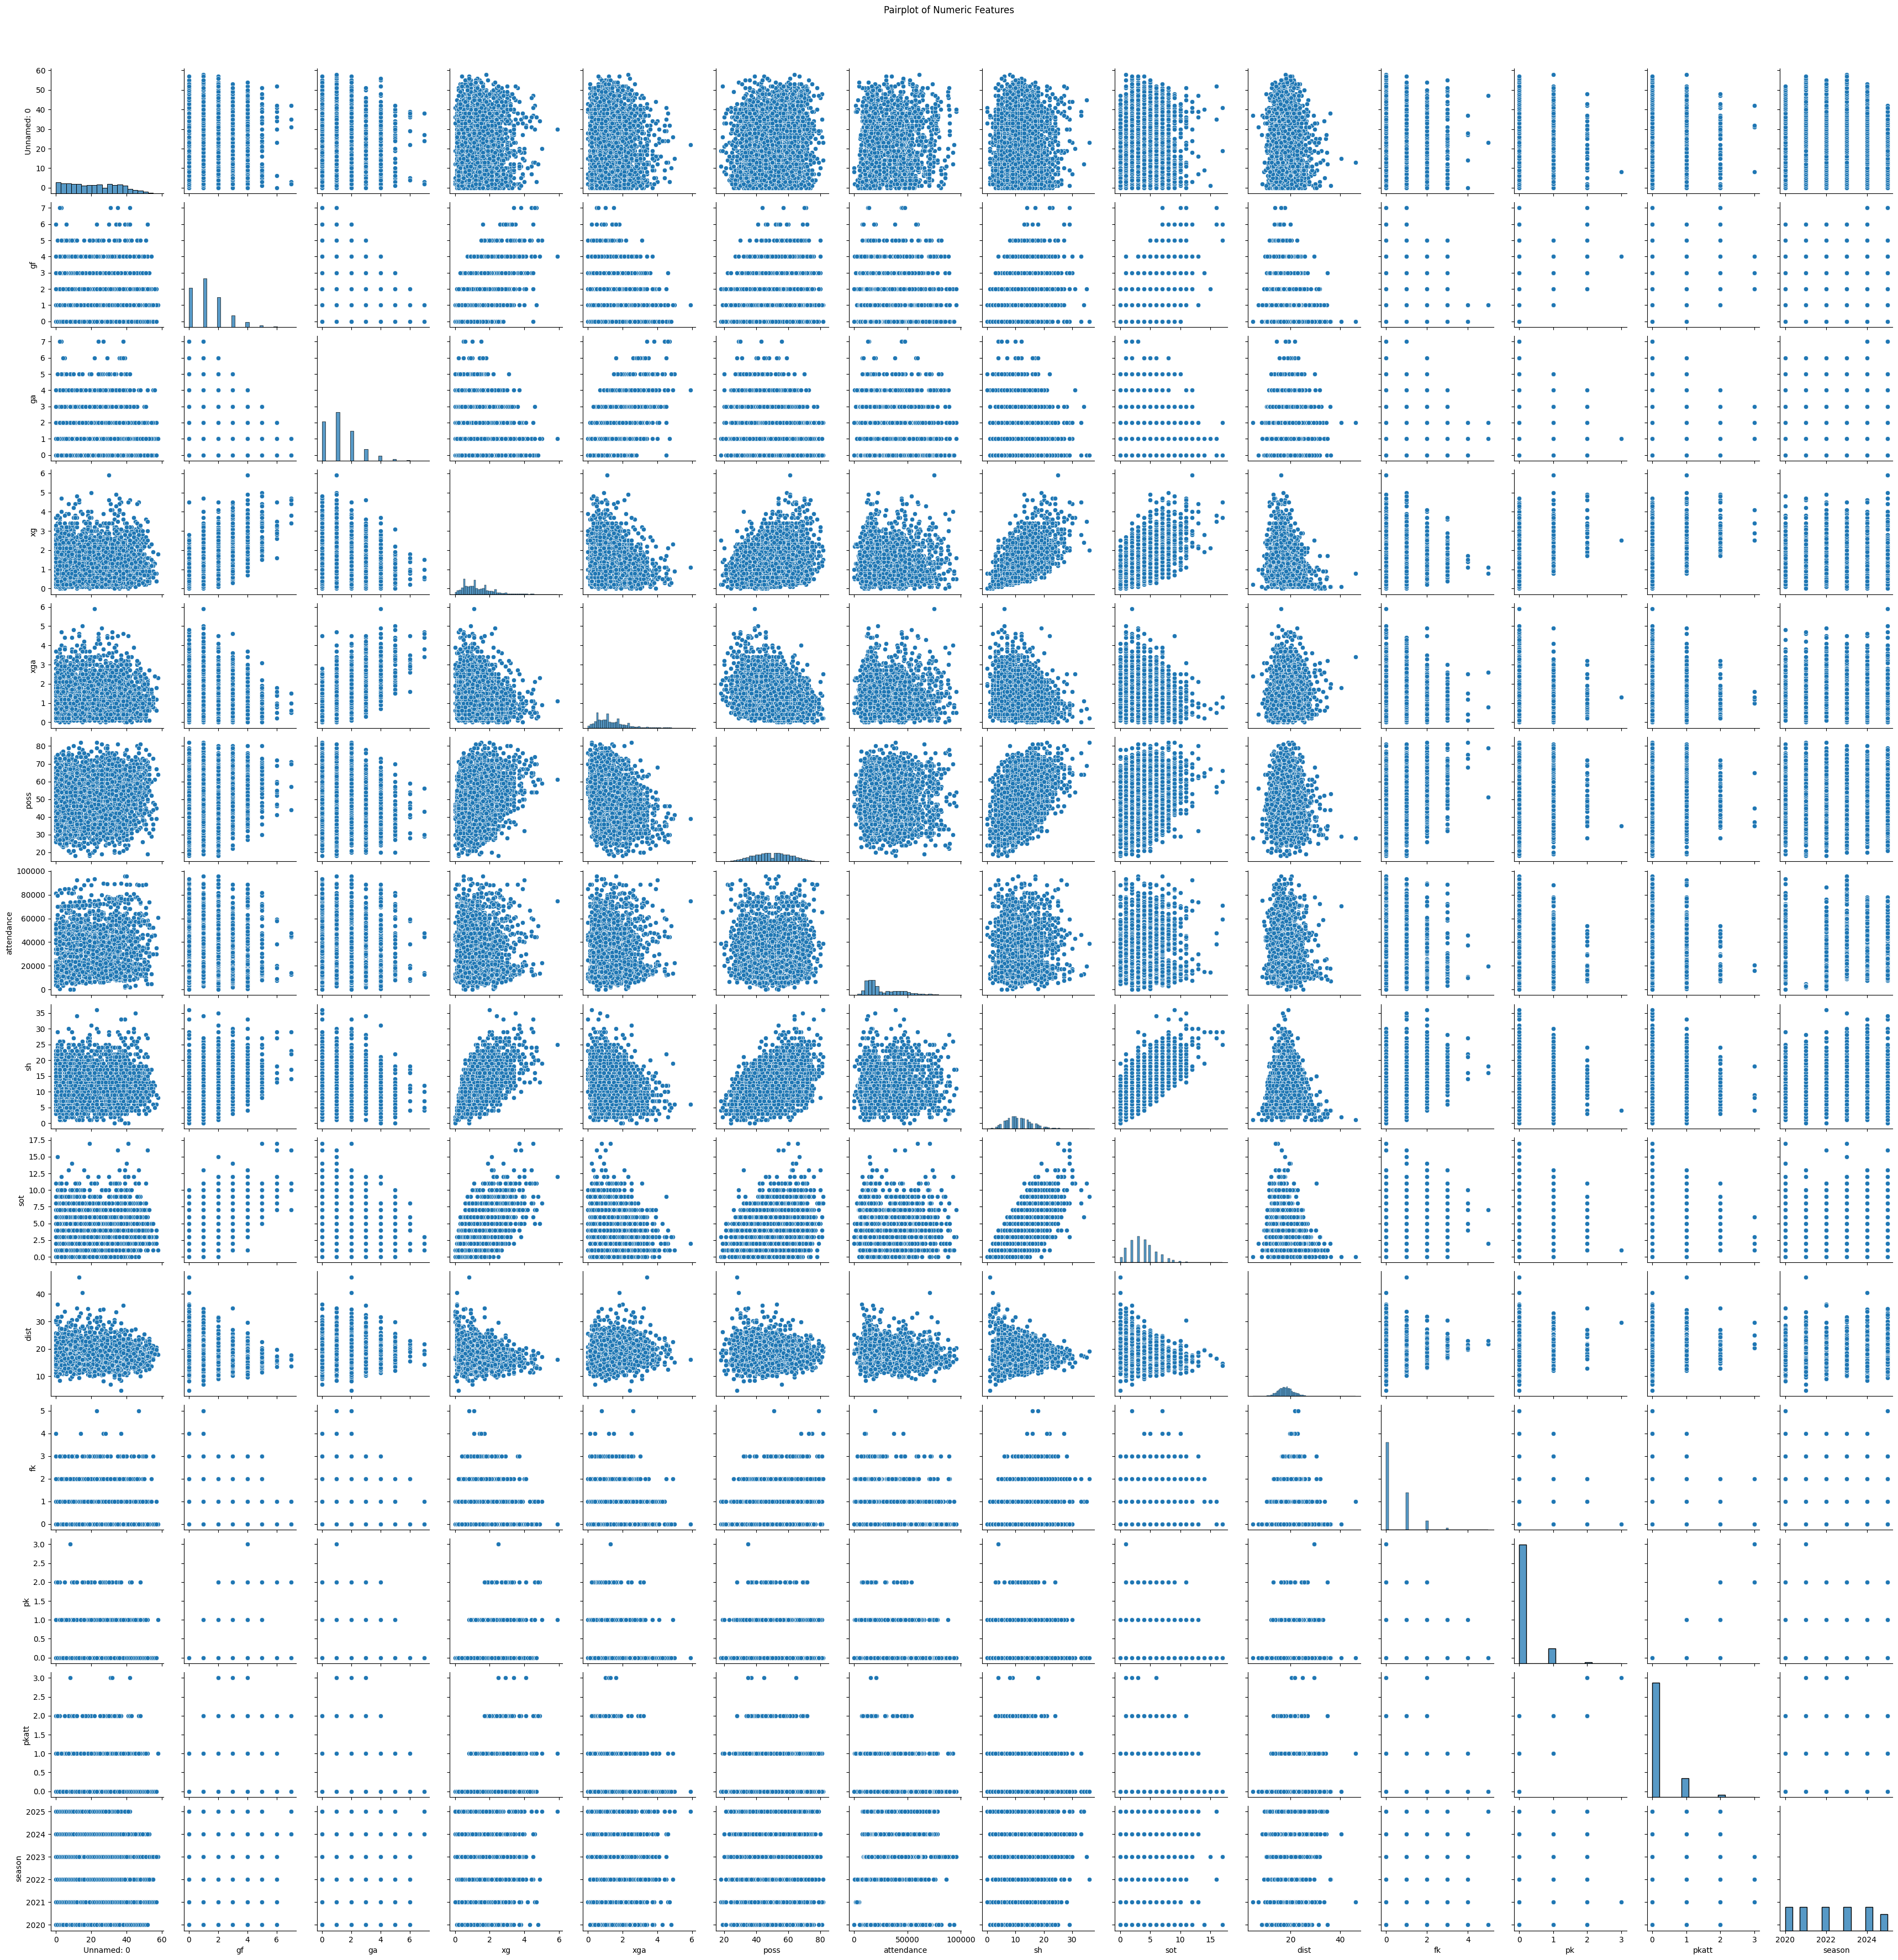

In [ ]:
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()